In [28]:
import numpy as np
import xarray as xr

asc_file = r"D:\Kuliah\Skripsi\Olah data\Gebco_malacca.asc"
wind_nc  = r"D:\Kuliah\Skripsi\Olah data\Data_Angin.nc"
out_bot  = r"D:\Kuliah\Skripsi\Olah data\SWAN\Malacca.bot"
out_wnd  = r"D:\Kuliah\Skripsi\Olah data\SWAN\Angin.wnd"

lon_min, lon_max = 97.5, 101.0
lat_min, lat_max = 3.0, 6.5

print("⏳ 1. Memproses Batimetri...")
header = {}
with open(asc_file, "r") as f:
    for _ in range(6):
        parts = f.readline().split()
        header[parts[0].lower()] = float(parts[1])

cell_bot = header["cellsize"] 
nodata = header.get("nodata_value", -32767)
data_bot = np.loadtxt(asc_file, skiprows=6)

lon_bot = header["xllcorner"] + np.arange(int(header["ncols"])) * cell_bot
lat_bot = header["yllcorner"] + np.arange(int(header["nrows"])) * cell_bot
lat_bot = lat_bot[::-1]

mask_lon = (lon_bot >= lon_min) & (lon_bot <= lon_max)
mask_lat = (lat_bot >= lat_min) & (lat_bot <= lat_max)

lon_crop = lon_bot[mask_lon]
lat_crop = lat_bot[mask_lat]
data_crop_bot = data_bot[np.ix_(mask_lat, mask_lon)].copy()

data_crop_bot[data_crop_bot == nodata] = np.nan
depth = -data_crop_bot 
depth[data_crop_bot >= 0] = -999.0 
depth = np.nan_to_num(depth, nan=-999.0)

nx_bot, ny_bot = len(lon_crop), len(lat_crop)

# Menulis Batimetri
with open(out_bot, "w") as f:
    for j in range(ny_bot):
        f.write(" ".join(f"{v:.2f}" for v in depth[j, :]) + "\n")

# HITUNGAN MATEMATIKA CGRID
dx_comp = 0.0083
dy_comp = 0.0083
xlenc_raw = lon_max - lon_min
ylenc_raw = lat_max - lat_min
mxc = int(round(xlenc_raw / dx_comp))
myc = int(round(ylenc_raw / dy_comp))
xlenc_safe = mxc * dx_comp
ylenc_safe = myc * dy_comp

print(f"✅ Batimetri Sukses! (Resolusi Komputasi Diset: {dx_comp}°)")

print("\n⏳ 2. Memproses Angin (Fase Penuh: 21 Nov - 2 Des)...")
ds = xr.open_dataset(wind_nc)
time_name = "valid_time" if "valid_time" in ds.dims else "time"

ds = ds.sortby(time_name, ascending=True).sortby('latitude', ascending=False).sortby('longitude', ascending=True)

# Ekstraksi waktu penuh Pra hingga Pasca Siklon
ds_crop = ds.sel(
    longitude=slice(lon_min, lon_max), 
    latitude=slice(lat_max, lat_min), 
    **{time_name: slice('2025-11-21', '2025-12-02')}
)

u = np.nan_to_num(ds_crop["u10"].values, nan=0.0) 
v = np.nan_to_num(ds_crop["v10"].values, nan=0.0)
nt_wnd = ds_crop.sizes[time_name]
nx_wnd = len(ds_crop.longitude)
ny_wnd = len(ds_crop.latitude)

time_delta = (ds_crop[time_name].values[1] - ds_crop[time_name].values[0]) / np.timedelta64(1, 'h')

# Menulis Angin
with open(out_wnd, "w") as f:
    for t in range(nt_wnd):
        for j in range(ny_wnd):
            f.write(" ".join(f"{val:.2f}" for val in u[t, j, :]) + "\n")
        for j in range(ny_wnd):
            f.write(" ".join(f"{val:.2f}" for val in v[t, j, :]) + "\n")
print(f"✅ Angin Sukses! Total {nt_wnd} jam terekstrak (12 Hari).")

print("\n" + "="*65)
print("🎯 COPY-PASTE SELURUH BARIS INI KE DALAM FILE swan.swn ANDA:")
print("="*65)
print(f"CGRID 95.0 1.5 0.0 {xlenc_safe:.4f} {ylenc_safe:.4f} {mxc} {myc} CIRCLE 36 0.04 1.0 24")
print("")
print(f"INPGRID BOTTOM 95.0 1.5 0.0 {nx_bot-1} {ny_bot-1} {cell_bot:.6f} {cell_bot:.6f} EXC -999.0")
print(f"READINP BOTTOM 1.0 'Malacca.bot' 1 0 FREE")
print("")
print(f"INPGRID WIND 95.0 1.5 0.0 {nx_wnd-1} {ny_wnd-1} 0.25 0.25 NONSTATIONARY 20251121.000000 {int(time_delta)} HR 20251202.230000")
print(f"READINP WIND 1.0 'Angin.wnd' 1 0 FREE")
print("="*65)

⏳ 1. Memproses Batimetri...
✅ Batimetri Sukses! (Resolusi Komputasi Diset: 0.0083°)

⏳ 2. Memproses Angin (Fase Penuh: 21 Nov - 2 Des)...
✅ Angin Sukses! Total 288 jam terekstrak (12 Hari).

🎯 COPY-PASTE SELURUH BARIS INI KE DALAM FILE swan.swn ANDA:
CGRID 95.0 1.5 0.0 3.5026 3.5026 422 422 CIRCLE 36 0.04 1.0 24

INPGRID BOTTOM 95.0 1.5 0.0 839 839 0.004167 0.004167 EXC -999.0
READINP BOTTOM 1.0 'Malacca.bot' 1 0 FREE

INPGRID WIND 95.0 1.5 0.0 14 14 0.25 0.25 NONSTATIONARY 20251121.000000 1 HR 20251202.230000
READINP WIND 1.0 'Angin.wnd' 1 0 FREE


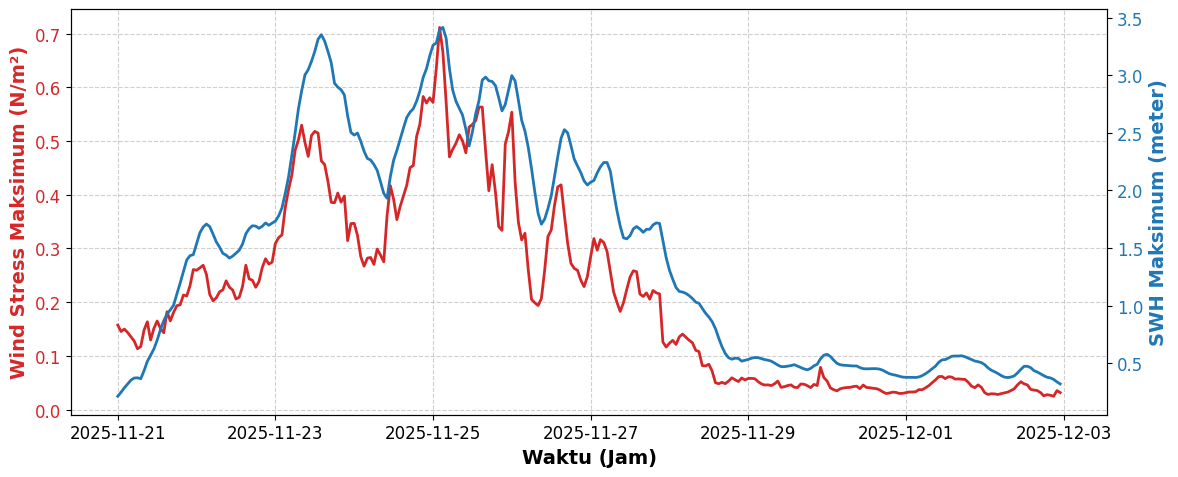

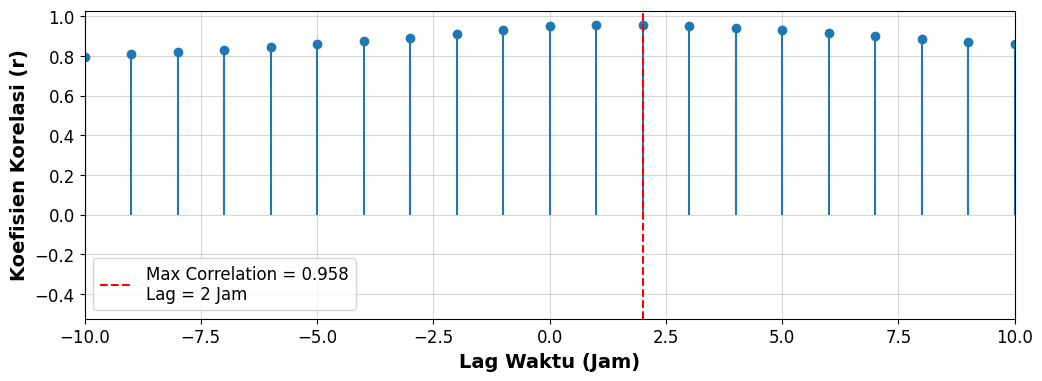

✅ Analisis Selesai!
👉 Korelasi maksimum terjadi pada Lag = 2 Jam dengan nilai r = 0.958
💡 Interpretasi: Kenaikan SWH memiliki jeda (fase lag) selama 2 jam SETELAH tegangan angin (wind stress) meningkat.


In [1]:
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.signal import correlate

# =====================================================================
# PENGATURAN FONT GLOBAL MATPLOTLIB
# =====================================================================
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 14,          # Ukuran font dasar
    'axes.labelsize': 14,     # Ukuran font label sumbu (X dan Y)
    'xtick.labelsize': 12,    # Ukuran font angka di sumbu X
    'ytick.labelsize': 12,    # Ukuran font angka di sumbu Y
    'legend.fontsize': 12     # Ukuran font pada kotak legenda
})
# =====================================================================

# 1. Load Data Output SWAN
file_path = r"D:\Kuliah\Skripsi\Olah data\SWAN 2\SWH_Output2.mat"
out_png_ts = r"D:\Kuliah\Skripsi\Olah data\ts_crop_stress.png"
out_png_cross = r"D:\Kuliah\Skripsi\Olah data\cross_crop_stress.png"
mat_data = sio.loadmat(file_path)

# 2. Ekstrak dan Urutkan Waktu (Timestamp) dari nama variabel
time_keys = sorted([k.replace('Hsig_', '') for k in mat_data.keys() if k.startswith('Hsig_')])

swh_series = []
wind_series = []
times = []

# 3. Looping untuk mengambil data maksimum (puncak badai) per jam
for t_key in time_keys:
    hsig = mat_data[f'Hsig_{t_key}']
    u_wind = mat_data[f'Windv_x_{t_key}']
    v_wind = mat_data[f'Windv_y_{t_key}']
    
    # Hitung kecepatan angin total dari vektor U dan V
    wind_spd = np.sqrt(u_wind**2 + v_wind**2)
    
    # Ambil nilai maksimum di perairan
    swh_series.append(np.nanmax(hsig))
    wind_series.append(np.nanmax(wind_spd))
    
    # Konversi ke format waktu Pandas untuk plotting
    times.append(pd.to_datetime(t_key, format='%Y%m%d_%H%M%S'))

# Ubah ke array numpy
swh_series = np.array(swh_series)
wind_series = np.array(wind_series)

# =====================================================================
# 3.5 KONVERSI WIND SPEED MENJADI WIND STRESS (WU, 1982)
# =====================================================================
rho_a = 1.225  # Massa jenis udara (kg/m^3)

# Menggunakan formulasi Drag Coefficient (Cd) dari Wu (1982) agar KONSISTEN dengan Peta Spasial
cd = (0.8 + 0.065 * wind_series) * 1e-3

# Menghitung Wind Stress magnitude (N/m^2)
wind_stress_series = rho_a * cd * (wind_series**2)
# =====================================================================

# 4. VISUALISASI DUAL-AXIS (TIME SERIES)
fig, ax1 = plt.subplots(figsize=(12, 5))

color = 'tab:red'
ax1.set_xlabel('Waktu (Jam)', fontweight='bold')
ax1.set_ylabel('Wind Stress Maksimum (N/m²)', color=color, fontweight='bold')
ax1.plot(times, wind_stress_series, color=color, linewidth=2, label='Wind Stress (Forcing)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.6)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('SWH Maksimum (meter)', color=color, fontweight='bold')
ax2.plot(times, swh_series, color=color, linewidth=2, linestyle='-', label='SWH (Response)')
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
plt.savefig(out_png_ts, dpi=1000, bbox_inches="tight", facecolor="white")
plt.show()

# 5. ANALISIS CROSS-CORRELATION
# Normalisasi data untuk CCF menggunakan array wind_stress_series
stress_norm = (wind_stress_series - np.mean(wind_stress_series)) / np.std(wind_stress_series)
swh_norm = (swh_series - np.mean(swh_series)) / np.std(swh_series)

# Hitung korelasi silang
ccf = correlate(swh_norm, stress_norm, mode='full') / len(stress_norm)
lags = np.arange(-len(stress_norm) + 1, len(stress_norm))

# Cari lag dengan korelasi tertinggi
max_corr_idx = np.argmax(ccf)
optimal_lag = lags[max_corr_idx]
max_corr_val = ccf[max_corr_idx]

# Lebar (figsize) diubah dari 10 ke 12 agar presisi dengan gambar di atasnya saat di Word
plt.figure(figsize=(12, 4)) 
plt.stem(lags, ccf, basefmt=" ")
plt.axvline(optimal_lag, color='red', linestyle='--', label=f'Max Correlation = {max_corr_val:.3f}\nLag = {optimal_lag} Jam')

plt.xlabel('Lag Waktu (Jam)', fontweight='bold')
plt.ylabel('Koefisien Korelasi (r)', fontweight='bold')
plt.xlim(-10, 10)
plt.grid(True, alpha=0.5)
plt.legend()
plt.savefig(out_png_cross, dpi=1000, bbox_inches="tight", facecolor="white")
plt.show()

print(f"✅ Analisis Selesai!")
print(f"👉 Korelasi maksimum terjadi pada Lag = {optimal_lag} Jam dengan nilai r = {max_corr_val:.3f}")
if optimal_lag > 0:
    print(f"💡 Interpretasi: Kenaikan SWH memiliki jeda (fase lag) selama {optimal_lag} jam SETELAH tegangan angin (wind stress) meningkat.")
elif optimal_lag == 0:
    print(f"💡 Interpretasi: SWH merespons secara instan bersamaan dengan lonjakan tegangan angin (tidak ada lag yang signifikan).")

Loading data SWAN resolusi tinggi...
✅ Berhasil memuat 288 titik waktu kontinu (Resolusi 1 Jam).

Extracting & Analyzing: Stasiun 1...


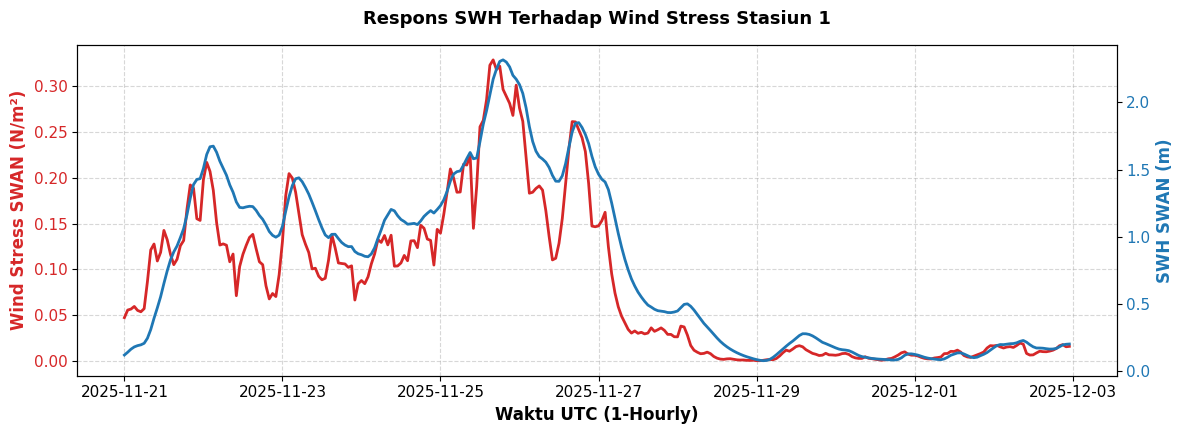

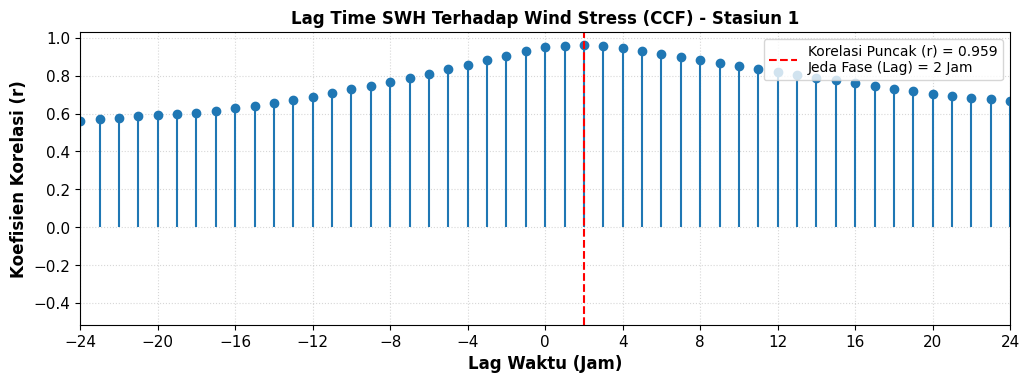

--> [HASIL KUNCI - Stasiun 1]
    Nilai Korelasi Tertinggi: r = 0.959
    Jeda Waktu Transmisi Energi (Lag): 2 Jam
    [Analisis Fisika]: Gelombang di Stasiun 1 mengalami fase time-lag. Puncak tinggi gelombang baru terbentuk 2 jam SETELAH hantaman tegangan angin siklon mencapai nilai maksimumnya.

Extracting & Analyzing: Stasiun 2...


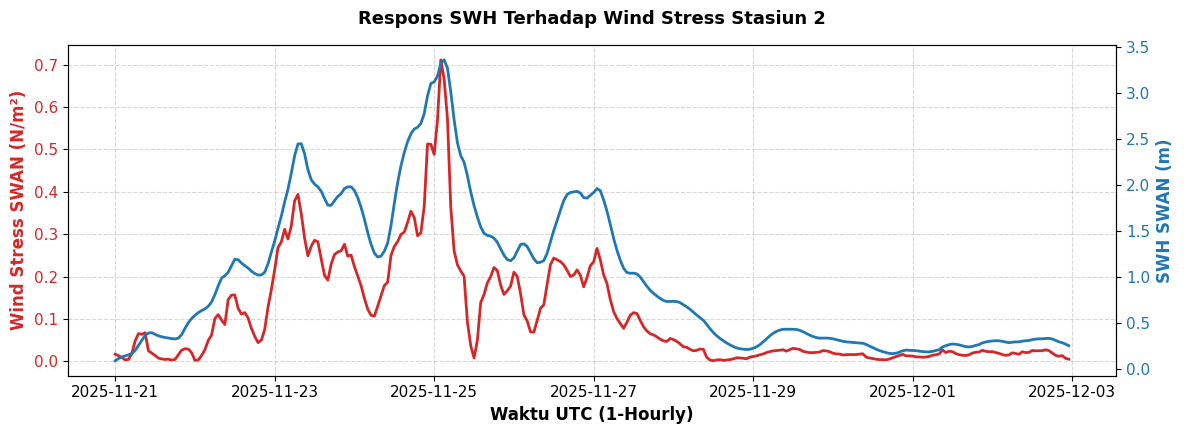

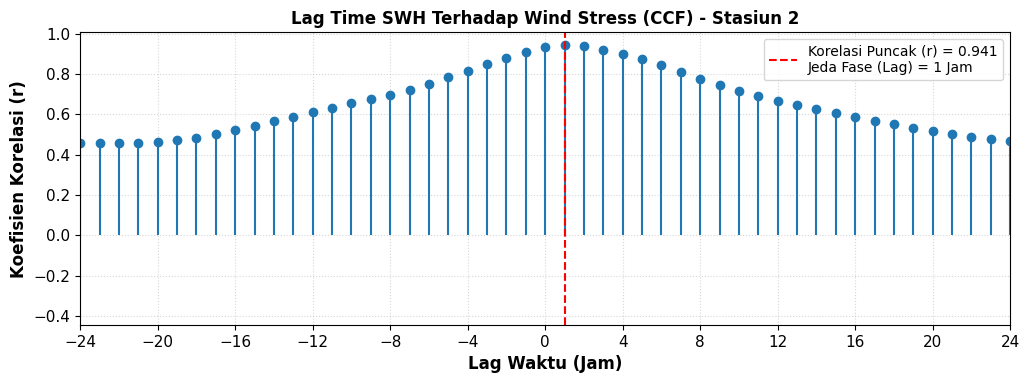

--> [HASIL KUNCI - Stasiun 2]
    Nilai Korelasi Tertinggi: r = 0.941
    Jeda Waktu Transmisi Energi (Lag): 1 Jam
    [Analisis Fisika]: Gelombang di Stasiun 2 mengalami fase time-lag. Puncak tinggi gelombang baru terbentuk 1 jam SETELAH hantaman tegangan angin siklon mencapai nilai maksimumnya.

Extracting & Analyzing: Stasiun 3...


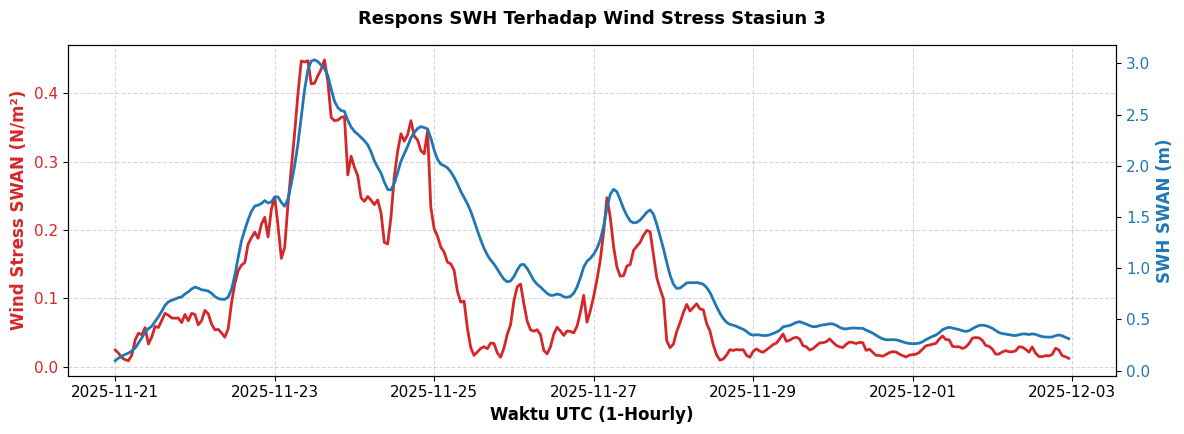

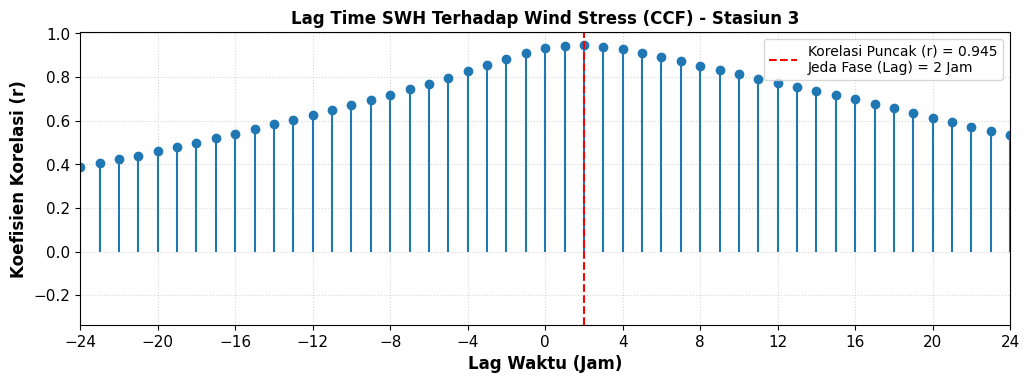

--> [HASIL KUNCI - Stasiun 3]
    Nilai Korelasi Tertinggi: r = 0.945
    Jeda Waktu Transmisi Energi (Lag): 2 Jam
    [Analisis Fisika]: Gelombang di Stasiun 3 mengalami fase time-lag. Puncak tinggi gelombang baru terbentuk 2 jam SETELAH hantaman tegangan angin siklon mencapai nilai maksimumnya.

✅ SELESAI! Grafik mekanisme interaksi Forcing-Response murni resolusi tinggi SWAN sukses dibuat.


In [18]:
import scipy.io as sio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import correlate
import os
import warnings

warnings.filterwarnings('ignore')

# =====================================================================
# PENGATURAN FONT GLOBAL MATPLOTLIB (Standar Jurnal/Skripsi)
# =====================================================================
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,          
    'axes.labelsize': 12,     
    'xtick.labelsize': 11,    
    'ytick.labelsize': 11,    
    'legend.fontsize': 10     
})

# =====================================================================
# 1. PENGATURAN FOLDER & PATH FILE SWAN MURNI
# =====================================================================
output_dir = r"D:\Kuliah\Skripsi\Olah data\Analisis_Mekanisme_SWAN"
os.makedirs(output_dir, exist_ok=True)

file_swan = r"D:\Kuliah\Skripsi\Olah data\SWAN 2\SWH_Output2.mat"

# =====================================================================
# 2. DEFINISI KOORDINAT 3 STASIUN VIRTUAL (Konsisten dengan Tujuan 2)
# =====================================================================
stasiun = {
    'Stasiun 1': (98.25, 5.75),
    'Stasiun 2': (99.25, 4.50),
    'Stasiun 3': (100.00, 3.50)
}

# =====================================================================
# 3. LOAD DATA & EKSTRAKSI WAKTU RESOLUSI TINGGI (1-HOURLY)
# =====================================================================
print("Loading data SWAN resolusi tinggi...")
mat_data = sio.loadmat(file_swan)

# Mengembalikan ke seluruh kunci waktu asli SWAN (Resolusi 1 Jam, Total 288 Jam)
time_keys = sorted([k.replace('Hsig_', '') for k in mat_data.keys() if k.startswith('Hsig_')])
times_dt = pd.to_datetime(time_keys, format='%Y%m%d_%H%M%S')
print(f"✅ Berhasil memuat {len(time_keys)} titik waktu kontinu (Resolusi 1 Jam).")

# Grid Spasial SWAN
lon_swan = np.linspace(97.5, 101.0, 423)
lat_swan = np.linspace(3.0, 6.5, 423)

# =====================================================================
# 4. LOOPING UTAMA ANALISIS MEKANISME PER STASIUN
# =====================================================================
rho_a = 1.225  # Massa jenis udara (kg/m^3)

for nama_stasiun, (lon_pt, lat_pt) in stasiun.items():
    print(f"\nExtracting & Analyzing: {nama_stasiun}...")
    
    # Cari indeks grid SWAN yang paling presisi menempel di stasiun virtual
    idx_lon = np.argmin(np.abs(lon_swan - lon_pt))
    idx_lat = np.argmin(np.abs(lat_swan - lat_pt))
    
    swan_u, swan_v, swan_swh = [], [], []
    
    # Ekstraksi seluruh 288 jam tanpa potongan
    for t_key in time_keys:
        swan_u.append(mat_data[f'Windv_x_{t_key}'][idx_lat, idx_lon])
        swan_v.append(mat_data[f'Windv_y_{t_key}'][idx_lat, idx_lon])
        swan_swh.append(mat_data[f'Hsig_{t_key}'][idx_lat, idx_lon])
        
    swan_u = np.array(swan_u)
    swan_v = np.array(swan_v)
    swan_swh = np.array(swan_swh)
    
    # Hitung Kecepatan Angin Total SWAN
    swan_wind_spd = np.sqrt(swan_u**2 + swan_v**2)
    
    # Hitung Tegangan Angin / Wind Stress SWAN (Formulasi Wu, 1982)
    cd_swan = (0.8 + 0.065 * swan_wind_spd) * 1e-3
    swan_stress = rho_a * cd_swan * (swan_wind_spd**2)
    
    # Masking nilai eror pesisir darat jika ada
    swan_swh = np.where(swan_swh <= 0, np.nan, swan_swh)
    swan_stress = np.where(np.isnan(swan_swh), np.nan, swan_stress)
    
    # -----------------------------------------------------------------
    # A. VISUALISASI DUAL-AXIS TIME SERIES (Full SWAN)
    # -----------------------------------------------------------------
    fig, ax1 = plt.subplots(figsize=(12, 4.5))
    
    # Sumbu Kiri: Wind Stress (Forcing)
    color_stress = 'tab:red'
    ax1.set_xlabel('Waktu UTC (1-Hourly)', fontweight='bold')
    ax1.set_ylabel('Wind Stress SWAN (N/m²)', color=color_stress, fontweight='bold')
    ax1.plot(times_dt, swan_stress, color=color_stress, linestyle='-', linewidth=2, label='Wind Stress (Forcing)')
    ax1.tick_params(axis='y', labelcolor=color_stress)
    ax1.grid(True, linestyle='--', alpha=0.5)
    
    # Sumbu Kanan: SWH (Response)
    ax2 = ax1.twinx()
    color_swh = 'tab:blue'
    ax2.set_ylabel('SWH SWAN (m)', color=color_swh, fontweight='bold')
    ax2.plot(times_dt, swan_swh, color=color_swh, linestyle='-', linewidth=2, label='SWH (Response)')
    ax2.tick_params(axis='y', labelcolor=color_swh)
    
    plt.title(f'Respons SWH Terhadap Wind Stress {nama_stasiun}', 
              fontweight='bold', pad=15, fontsize=13)
    fig.tight_layout()
    
    # Simpan Grafik Time Series
    nama_safe = nama_stasiun.lower().replace(' ', '_').replace('(', '').replace(')', '')
    file_png_ts = os.path.join(output_dir, f"ts_swan_pure_{nama_safe}.png")
    plt.savefig(file_png_ts, dpi=500, bbox_inches="tight", facecolor="white")
    plt.show()
    
    # -----------------------------------------------------------------
    # B. ANALISIS CROSS-CORRELATION FUNCTION (CCF dengan Presisi 1 Jam)
    # -----------------------------------------------------------------
    # Bersihkan data dari komponen kosong sebelum perhitungan statistik
    valid_idx = ~np.isnan(swan_stress) & ~np.isnan(swan_swh)
    stress_valid = swan_stress[valid_idx]
    swh_valid = swan_swh[valid_idx]
    
    # Normalisasi data
    stress_norm = (stress_valid - np.mean(stress_valid)) / np.std(stress_valid)
    swh_norm = (swh_valid - np.mean(swh_valid)) / np.std(swh_valid)
    
    # Hitung Korelasi Silang
    ccf = correlate(swh_norm, stress_norm, mode='full') / len(stress_norm)
    lags = np.arange(-len(stress_norm) + 1, len(stress_norm))
    
    # Cari indeks korelasi puncak dan lag optimum
    max_corr_idx = np.argmax(ccf)
    optimal_lag = lags[max_corr_idx]
    max_corr_val = ccf[max_corr_idx]
    
    # Plotting Grafik Kontinu Stem CCF
    plt.figure(figsize=(12, 3.8)) 
    plt.stem(lags, ccf, basefmt=" ")
    plt.axvline(optimal_lag, color='red', linestyle='--', 
                label=f'Korelasi Puncak (r) = {max_corr_val:.3f}\nJeda Fase (Lag) = {optimal_lag} Jam')
    
    plt.xlabel('Lag Waktu (Jam)', fontweight='bold')
    plt.ylabel('Koefisien Korelasi (r)', fontweight='bold')
    
    # Batasan jendela diperluas ke 24 jam agar terlihat tren sebelum/sesudah siklon melintas
    plt.xlim(-24, 24) 
    plt.xticks(np.arange(-24, 25, 4)) # Grid penanda per 4 jam
    plt.grid(True, alpha=0.5, linestyle=':')
    plt.legend(loc='upper right')
    plt.title(f'Lag Time SWH Terhadap Wind Stress (CCF) - {nama_stasiun}', fontweight='bold', fontsize=12)
    
    # Simpan Grafik CCF
    file_png_cross = os.path.join(output_dir, f"cross_swan_pure_{nama_safe}.png")
    plt.savefig(file_png_cross, dpi=500, bbox_inches="tight", facecolor="white")
    plt.show()
    
    # Narasi Akademik untuk Konsol Pembahasan Anda
    print(f"--> [HASIL KUNCI - {nama_stasiun}]")
    print(f"    Nilai Korelasi Tertinggi: r = {max_corr_val:.3f}")
    print(f"    Jeda Waktu Transmisi Energi (Lag): {optimal_lag} Jam")
    if optimal_lag > 0:
        print(f"    [Analisis Fisika]: Gelombang di {nama_stasiun} mengalami fase time-lag. Puncak tinggi gelombang baru terbentuk {optimal_lag} jam SETELAH hantaman tegangan angin siklon mencapai nilai maksimumnya.")
    elif optimal_lag == 0:
        print(f"    [Analisis Fisika]: Respons perairan bersifat instan (0-lag). Gelombang bertumbuh serempak seiring dengan transfer energi linier dari angin badai.")
    else:
        print(f"    [Analisis Fisika]: Nilai negatif mengindikasikan gelombang mendahului angin lokal (didominasi oleh refraksi swell).")

print("\n✅ SELESAI! Grafik mekanisme interaksi Forcing-Response murni resolusi tinggi SWAN sukses dibuat.")

In [2]:
import numpy as np

file_asc = r"D:\Kuliah\Skripsi\Olah data\Gebco_malacca.asc"
file_bot = r"D:\Kuliah\Skripsi\Olah data\SWAN 2\Malacca2.bot"

print("⏳ Sedang mengonversi .asc menjadi .bot...")

data_batimetri = np.loadtxt(file_asc, skiprows=6)

np.savetxt(file_bot, data_batimetri, fmt="%.2f")

print(f"✅ Konversi selesai! File tersimpan di: {file_bot}")

⏳ Sedang mengonversi .asc menjadi .bot...
✅ Konversi selesai! File tersimpan di: D:\Kuliah\Skripsi\Olah data\SWAN 2\Malacca2.bot


⏳ Membaca dan memotong data raster BATNAS...
⏳ Menggambar Peta Batimetri...


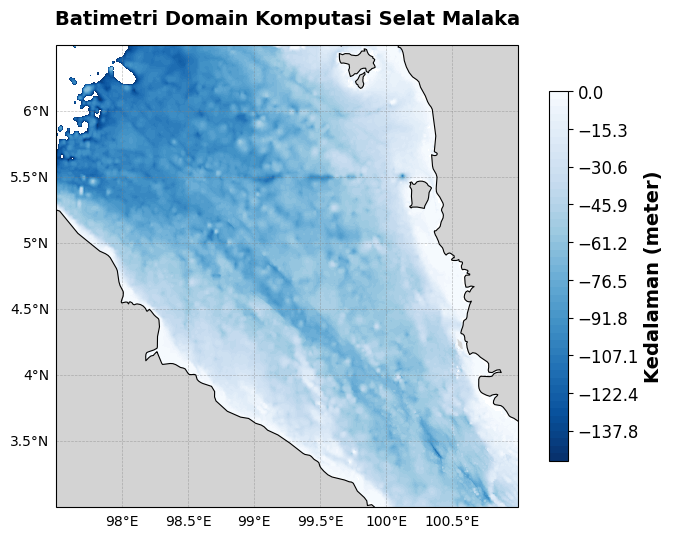

⏳ Menggambar Peta Grid SWAN...


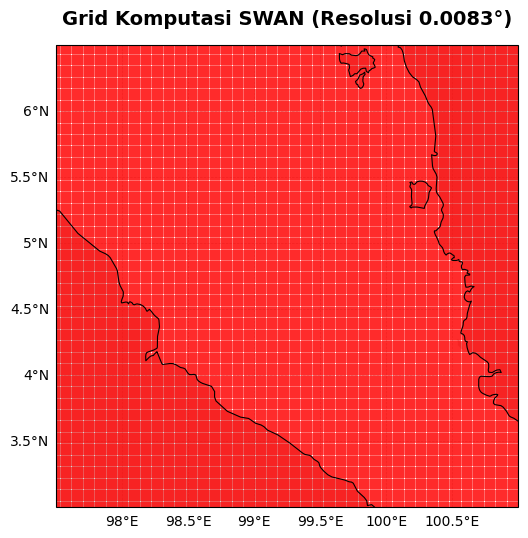

✅ SELESAI


In [44]:
import xarray as xr
import rioxarray
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ==========================================
# 1. BUKA DATA BATIMETRI BATNAS (.asc)
# ==========================================
file_bathy = r"D:\Kuliah\Skripsi\Olah data\Gebco_malacca.asc" 

print("⏳ Membaca dan memotong data raster BATNAS...")
ds = rioxarray.open_rasterio(file_bathy)
ds.rio.write_crs("epsg:4326", inplace=True)

# Batas Domain Komputasi Selat Malaka
lon_min, lon_max = 97.5, 101.0
lat_min, lat_max = 3.0, 6.5

# Memotong wilayah khusus Selat Malaka
bathy_crop = ds.rio.clip_box(minx=lon_min, miny=lat_min, maxx=lon_max, maxy=lat_max)

# Ekstrak koordinat
lon = bathy_crop['x'].values
lat = bathy_crop['y'].values

# Ambil matriks angka kedalaman (berada di band indeks 0)
z = bathy_crop.values[0]

# ==========================================
# 2. FILTERING DATA (Masking Daratan & Nilai Kosong)
# ==========================================
z = np.where(z == -9999, np.nan, z) 

# Masking daratan (nilai > 0)
z_laut = np.ma.masked_where((z > 0) | (np.isnan(z)), z)

# ==========================================
# FUNGSI PEMBUATAN PETA DASAR
# ==========================================
def setup_map(ax, title):
    # Tambahkan Daratan dan Garis Pantai
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=3)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    
    # Atur Grid koordinat pinggir
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 10}
    gl.ylabel_style = {'size': 10}
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)

# ==========================================
# 3. GAMBAR 1: PETA BATIMETRI
# ==========================================
print("⏳ Menggambar Peta Batimetri...")
fig1 = plt.figure(figsize=(8, 6))
ax1 = plt.axes(projection=ccrs.PlateCarree())
setup_map(ax1, 'Batimetri Domain Komputasi Selat Malaka')

# Plot kontur kedalaman laut
contour_bathy = ax1.contourf(lon, lat, z_laut, levels=np.linspace(-150, 0, 50), cmap='Blues_r', transform=ccrs.PlateCarree(), zorder=1)
cbar = plt.colorbar(contour_bathy, ax=ax1, shrink=0.8)
cbar.set_label('Kedalaman (meter)', fontsize=14, fontweight='bold')

plt.savefig(r"D:\Kuliah\Skripsi\Olah data\Peta_Batimetri.png", dpi=600, bbox_inches='tight', facecolor='white')
plt.show()

# ==========================================
# 4. GAMBAR 2: PETA GRID KOMPUTASI
# ==========================================
print("⏳ Menggambar Peta Grid SWAN...")
fig2 = plt.figure(figsize=(8, 6))
ax2 = plt.axes(projection=ccrs.PlateCarree())
setup_map(ax2, 'Grid Komputasi SWAN (Resolusi 0.0083°)')

# Membuat visualisasi jaring-jaring
grid_lon = np.arange(lon_min, lon_max + 0.1, 0.0083)
grid_lat = np.arange(lat_min, lat_max + 0.1, 0.0083)

for glon in grid_lon:
    ax2.plot([glon, glon], [lat_min, lat_max], color='red', linewidth=0.6, alpha=0.7, transform=ccrs.PlateCarree())

for glat in grid_lat:
    ax2.plot([lon_min, lon_max], [glat, glat], color='red', linewidth=0.6, alpha=0.7, transform=ccrs.PlateCarree())

plt.savefig(r"D:\Kuliah\Skripsi\Olah data\Peta_Grid.png", dpi=600, bbox_inches='tight', facecolor='white')
plt.show()

print("✅ SELESAI")

In [45]:
# Ambil salah satu sampel jam
tes_swh = mat_data[f'Hsig_{swan_time_keys[0]}']

print("--- DIAGNOSTIK DATA SWAN ---")
print("Ukuran Matriks (Shape) :", tes_swh.shape)
print("Nilai Maksimum         :", np.nanmax(tes_swh))
print("Nilai Minimum          :", np.nanmin(tes_swh))
print("Total Titik Koordinat  :", tes_swh.size)
print("Titik yang Berisi Air  :", np.sum(tes_swh > 0))

--- DIAGNOSTIK DATA SWAN ---
Ukuran Matriks (Shape) : (423, 423)
Nilai Maksimum         : 3.2602353
Nilai Minimum          : 0.0
Total Titik Koordinat  : 178929
Titik yang Berisi Air  : 120430


✅ SELESAI


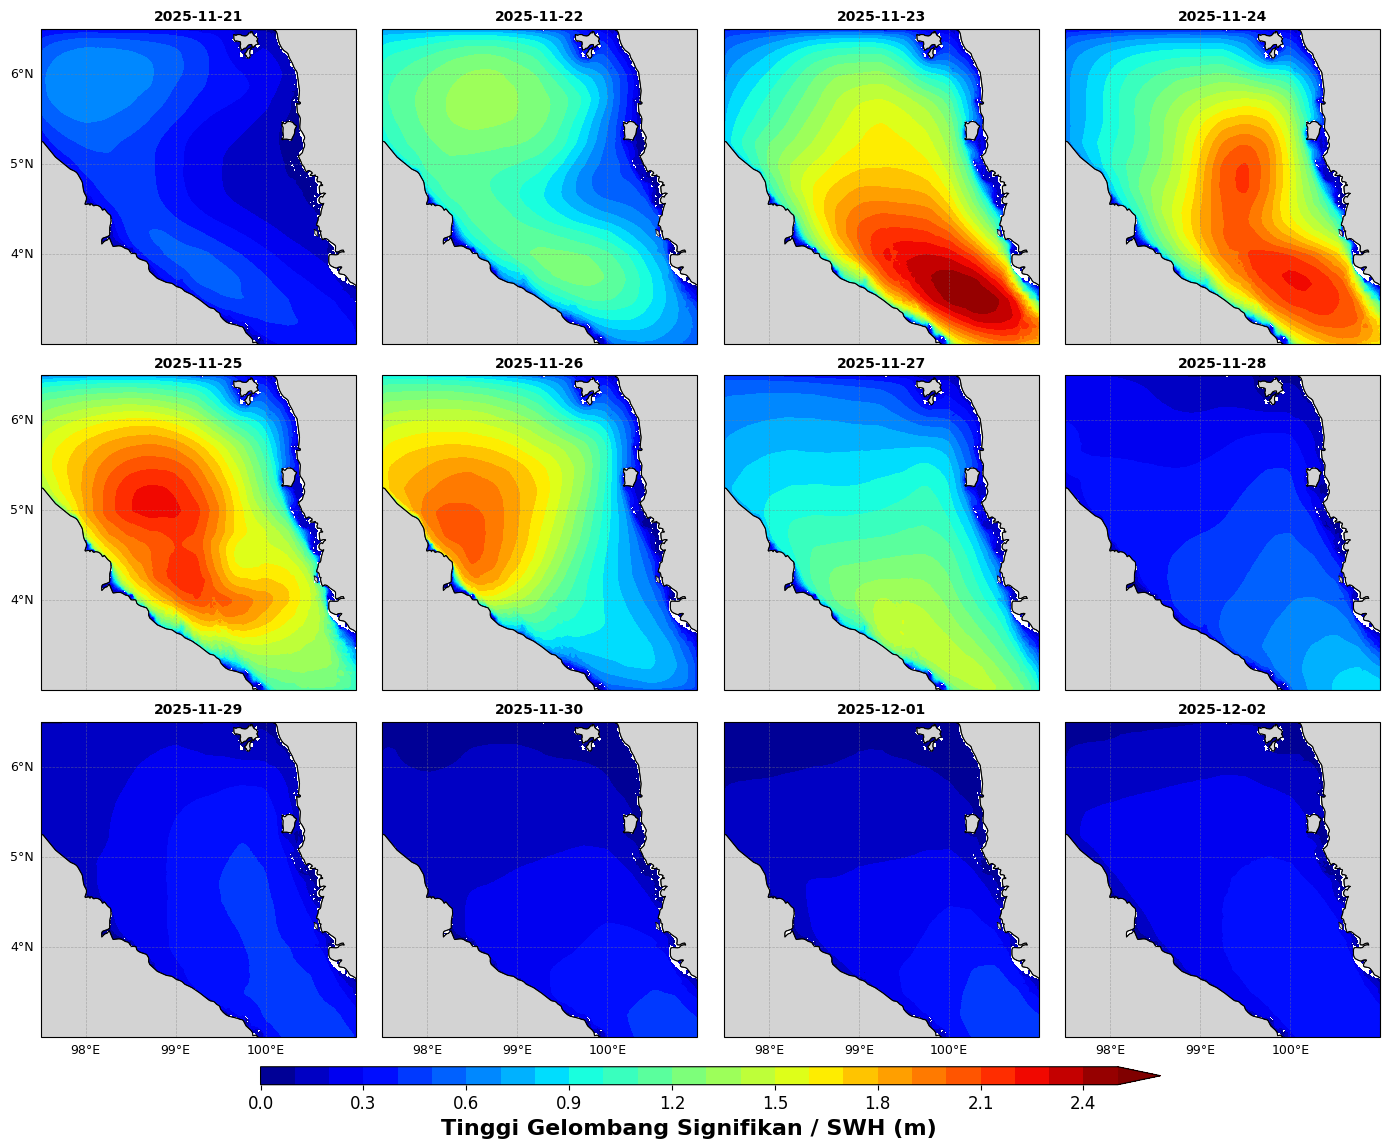

In [20]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
import warnings

warnings.filterwarnings('ignore')

# =====================================================================
# 1. PENGATURAN FONT MS WORD
# =====================================================================
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 16
})

file_swan = r"D:\Kuliah\Skripsi\Olah data\SWAN 2\SWH_Output2.mat"
out_png = r"D:\Kuliah\Skripsi\Olah data\Distribusi Spasial SWH SWAN.png"

lon_min, lon_max = 97.5, 101.0
lat_min, lat_max = 3.0, 6.5

# =====================================================================
# 2. LOAD DATA
# =====================================================================
mat_data = sio.loadmat(file_swan)

lon_swan = np.linspace(lon_min, lon_max, 423)
lat_swan = np.linspace(lat_min, lat_max, 423)
X_swan, Y_swan = np.meshgrid(lon_swan, lat_swan)

time_keys = sorted([k.replace('Hsig_', '') for k in mat_data.keys() if k.startswith('Hsig_')])
unique_days = sorted(list(set([t[:8] for t in time_keys])))

# =====================================================================
# 3. PERSIAPAN FIGURE
# =====================================================================
fig, axes = plt.subplots(3, 4, figsize=(15, 12), subplot_kw={'projection': ccrs.PlateCarree()})
axes_flat = axes.flatten()

clevs = np.arange(0, 2.6, 0.1) 
cmap_choice = 'jet'

def format_map(ax, title, baris, kolom):
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5, zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=3)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.xlocator = mticker.MultipleLocator(1)
    gl.ylocator = mticker.MultipleLocator(1)
    gl.xlabel_style = {'size': 9, 'color': 'black'}
    gl.ylabel_style = {'size': 9, 'color': 'black'}
    
    gl.top_labels = False
    gl.right_labels = False
    
    if kolom > 0:
        gl.left_labels = False   
    if baris < 2:
        gl.bottom_labels = False 
        
    ax.set_title(title, fontweight='bold', pad=6, fontsize=10)

# =====================================================================
# 4. LOOPING & PLOTTING
# =====================================================================
for i, day in enumerate(unique_days):
    ax = axes_flat[i]
    day_keys = [k for k in time_keys if k.startswith(day)]
    
    hourly_hsig = [mat_data[f'Hsig_{t}'] for t in day_keys]
    avg_hsig = np.nanmean(np.array(hourly_hsig), axis=0)
    avg_hsig = np.where(avg_hsig <= 0, np.nan, avg_hsig)
    
    cf = ax.contourf(X_swan, Y_swan, avg_hsig, levels=clevs, cmap=cmap_choice, extend='max', transform=ccrs.PlateCarree(), zorder=1)
    
    tanggal_format = f"{day[:4]}-{day[4:6]}-{day[6:8]}"
    
    baris = i // 4
    kolom = i % 4
    format_map(ax, tanggal_format, baris, kolom)

# =====================================================================
# 5. PENYESUAIAN LAYOUT (MENIRU REFERENSI ERA5)
# =====================================================================
plt.subplots_adjust(left=0.05, right=0.95, top=0.92, bottom=0.08, wspace=0.05, hspace=0.1)

cbar_ax = fig.add_axes([0.2, 0.04, 0.6, 0.015]) 
cbar = fig.colorbar(cf, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Tinggi Gelombang Signifikan / SWH (m)', fontsize=16, fontweight='bold')

fig.savefig(out_png, dpi=600, bbox_inches='tight', facecolor='white')
print("✅ SELESAI")

✅ SELESAI


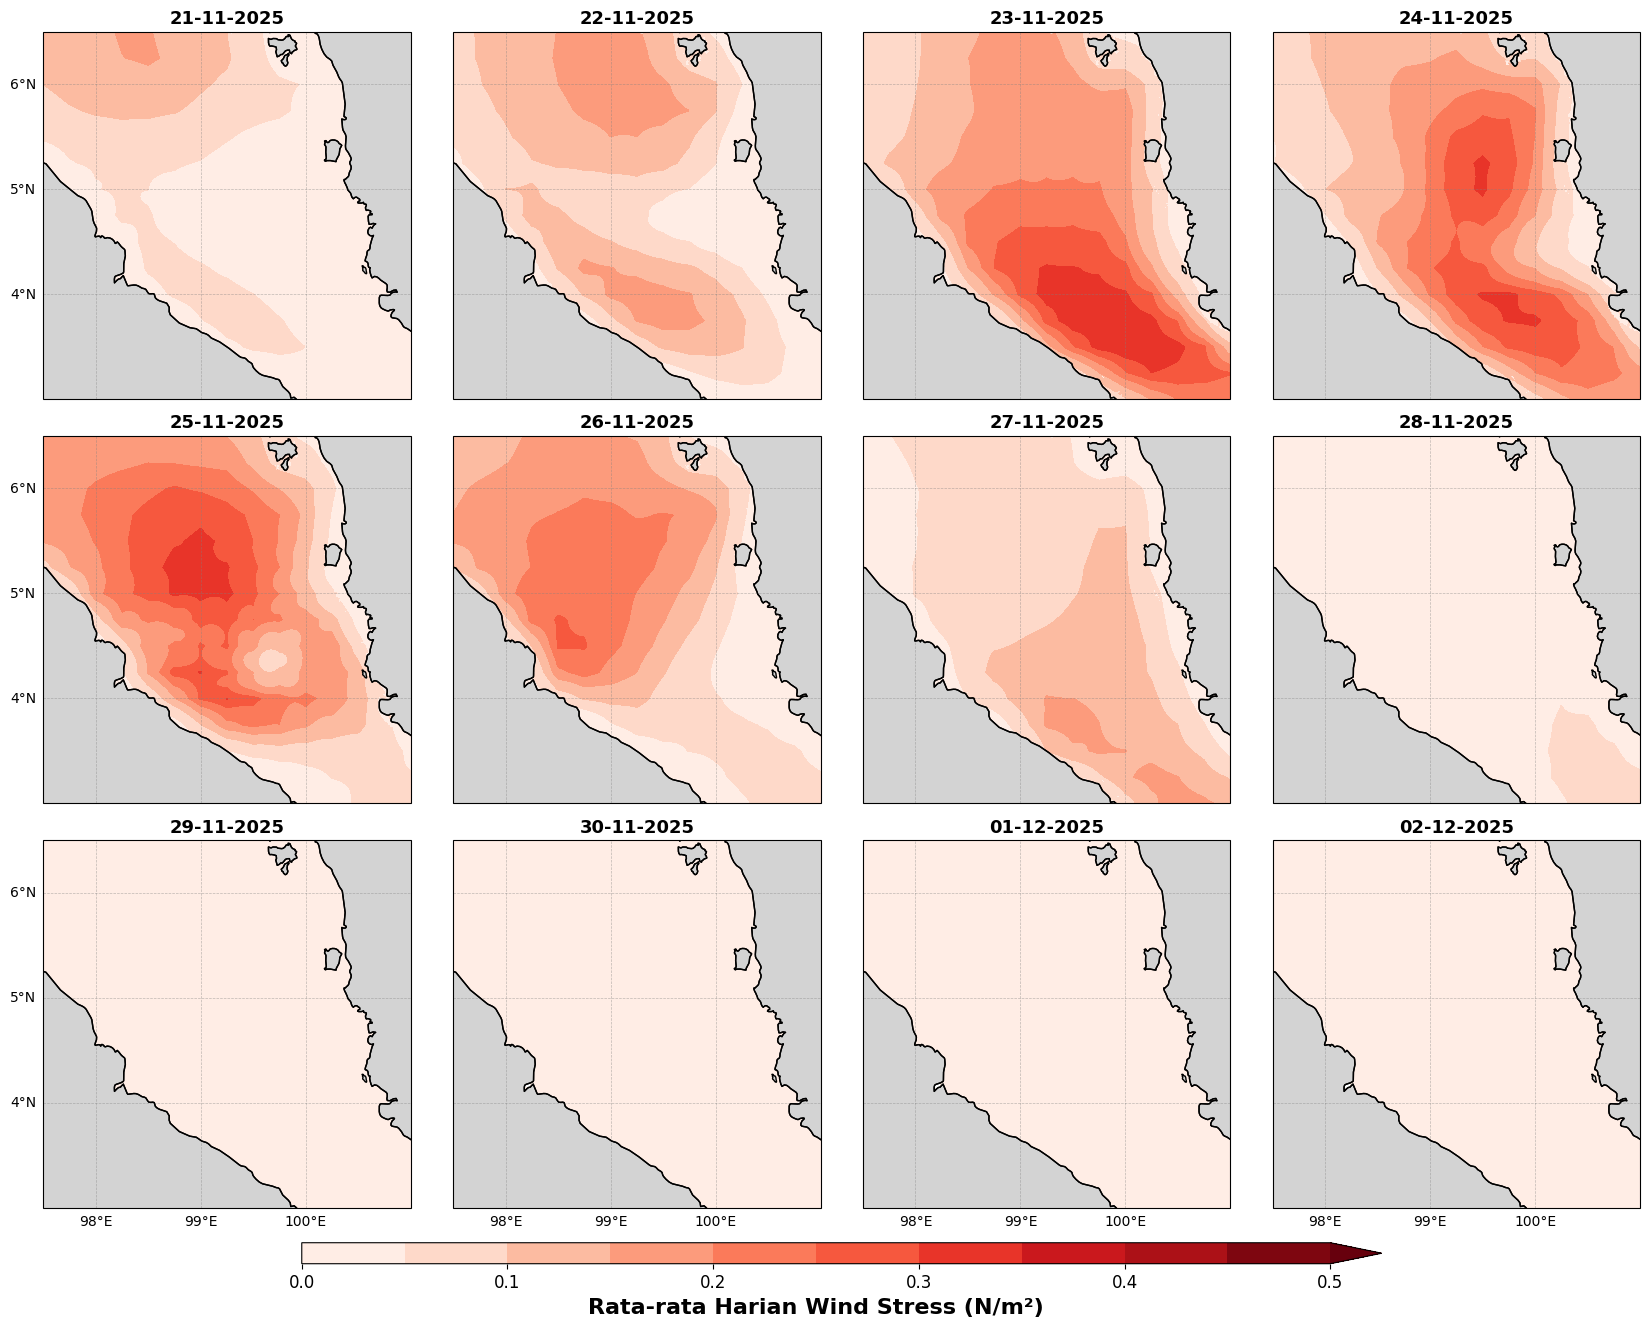

In [12]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
import warnings

# Abaikan warning pembagian NaN saat rata-rata
warnings.filterwarnings('ignore')

# 1. PENGATURAN FONT GLOBAL
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 16
})

# 2. DEFINISI FILE & PARAMETER DOMAIN
file_swan = r"D:\Kuliah\Skripsi\Olah data\SWAN 2\SWH_Output2.mat"
out_png = r"D:\Kuliah\Skripsi\Olah data\Distribusi Spasial WS SWAN.png"

lon_min, lon_max = 97.5, 101.0
lat_min, lat_max = 3.0, 6.5

# 3. LOAD DATA & EKSTRAKSI DAFTAR HARI
mat_data = sio.loadmat(file_swan)

lon_swan = np.linspace(lon_min, lon_max, 423)
lat_swan = np.linspace(lat_min, lat_max, 423)
X_swan, Y_swan = np.meshgrid(lon_swan, lat_swan)

# Ekstrak semua kunci waktu dan kelompokkan berdasarkan tanggal
time_keys = sorted([k.replace('Hsig_', '') for k in mat_data.keys() if k.startswith('Hsig_')])
unique_days = sorted(list(set([t[:8] for t in time_keys])))

# 4. PERSIAPAN FIGURE
fig, axes = plt.subplots(3, 4, figsize=(18, 14), subplot_kw={'projection': ccrs.PlateCarree()})
axes_flat = axes.flatten()

clevs = np.linspace(0, 0.5, 11) 
skip = (slice(None, None, 15), slice(None, None, 15)) 

def format_map(ax, title, baris, kolom):
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=1.0, zorder=3)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    
    # Grid tiap 1 derajat
    gl.xlocator = mticker.MultipleLocator(1)
    gl.ylocator = mticker.MultipleLocator(1)
    gl.xlabel_style = {'size': 10}
    gl.ylabel_style = {'size': 10}
    
    gl.top_labels = False
    gl.right_labels = False
    
    if kolom > 0:
        gl.left_labels = False   
    if baris < 2:
        gl.bottom_labels = False 
        
    ax.set_title(title, fontweight='bold', pad=6, fontsize=13)

# 5. PEMROSESAN RATA-RATA HARIAN & PLOTTING
rho_a = 1.225

for i, day in enumerate(unique_days):
    ax = axes_flat[i]
    day_keys = [k for k in time_keys if k.startswith(day)]
    
    hourly_stress = []
    hourly_u = []
    hourly_v = []
    hourly_mask = []
    
    for t_key in day_keys:
        u = mat_data[f'Windv_x_{t_key}']
        v = mat_data[f'Windv_y_{t_key}']
        hsig = mat_data[f'Hsig_{t_key}']
        
        ws = np.sqrt(u**2 + v**2)
        cd = (0.8 + 0.065 * ws) * 1e-3
        tau = rho_a * cd * (ws**2)
        
        hourly_stress.append(tau)
        hourly_u.append(u)
        hourly_v.append(v)
        hourly_mask.append(hsig)
    
    # Rata-rata harian
    avg_tau = np.nanmean(np.array(hourly_stress), axis=0)
    avg_u = np.nanmean(np.array(hourly_u), axis=0)
    avg_v = np.nanmean(np.array(hourly_v), axis=0)
    
    max_hsig_day = np.nanmax(np.array(hourly_mask), axis=0)
    avg_tau = np.where(max_hsig_day <= 0, np.nan, avg_tau)
    avg_u = np.where(max_hsig_day <= 0, np.nan, avg_u)
    avg_v = np.where(max_hsig_day <= 0, np.nan, avg_v)
    
    cf = ax.contourf(X_swan, Y_swan, avg_tau, levels=clevs, cmap='Reds', extend='max', transform=ccrs.PlateCarree(), zorder=1)
    #ax.quiver(X_swan[skip], Y_swan[skip], avg_u[skip], avg_v[skip], 
              #color='black', alpha=0.8, scale=250, transform=ccrs.PlateCarree(), zorder=4)
    
    tanggal_format = f"{day[6:8]}-{day[4:6]}-{day[:4]}"
    
    baris = i // 4
    kolom = i % 4
    format_map(ax, f'{tanggal_format}', baris, kolom)

# 6. PENYESUAIAN LAYOUT & COLORBAR
plt.subplots_adjust(left=0.05, right=0.95, top=0.92, bottom=0.08, wspace=0.05, hspace=0.1)

cbar_ax = fig.add_axes([0.2, 0.04, 0.6, 0.015]) 
cbar = fig.colorbar(cf, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Rata-rata Harian Wind Stress (N/m²)', fontsize=16, fontweight='bold')

fig.savefig(out_png, dpi=800, bbox_inches='tight', facecolor='white')
print("✅ SELESAI")

In [49]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
import os
import glob
from PIL import Image

# 1. PERSIAPAN FOLDER
output_dir = r"D:\Kuliah\Skripsi\Olah data\Animasi_SWH_SWAN"
os.makedirs(output_dir, exist_ok=True)

mat_data = sio.loadmat(r"D:\Kuliah\Skripsi\Olah data\SWAN 2\SWH_Output2.mat")
time_keys = sorted([k.replace('Hsig_', '') for k in mat_data.keys() if k.startswith('Hsig_')])

lon_swan = np.linspace(97.5, 101.0, 423)
lat_swan = np.linspace(3.0, 6.5, 423)
X, Y = np.meshgrid(lon_swan, lat_swan)

MODE = "SWH" 

# 2. PLOTTING PER JAM
print(f"Memulai proses render frame ke folder...")
for i, t_key in enumerate(time_keys):
    fig, ax = plt.subplots(figsize=(8, 7), subplot_kw={'projection': ccrs.PlateCarree()})
    
    # Data
    val = mat_data[f'Hsig_{t_key}'] if MODE == "SWH" else np.sqrt(mat_data[f'Windv_x_{t_key}']**2 + mat_data[f'Windv_y_{t_key}']**2)
    val = np.where(mat_data[f'Hsig_{t_key}'] <= 0, np.nan, val)
    
    # Plotting
    clevs = np.linspace(0, 3.0, 21) if MODE == "SWH" else np.linspace(0, 0.6, 21)
    cmap = 'jet' if MODE == "SWH" else 'Reds'
    
    cf = ax.contourf(X, Y, val, levels=clevs, cmap=cmap, extend='max', transform=ccrs.PlateCarree())
    
    # Peta dasar
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black')
    ax.add_feature(cfeature.COASTLINE)
    ax.set_extent([97.5, 101.0, 3.0, 6.5])
    
    # Judul & Waktu
    ax.set_title(f'{MODE} - {t_key[:8]} {t_key[9:11]}:{t_key[11:13]} WIB', fontweight='bold')
    
    save_path = os.path.join(output_dir, f"{MODE}_{t_key}.png")
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"Progress: {i+1}/{len(time_keys)}", end='\r')

# 3. PEMBUATAN GIF
print("\nMenjahit frame menjadi GIF...")
images = [Image.open(f) for f in sorted(glob.glob(os.path.join(output_dir, f"{MODE}_*.png")))]
images[0].save(
    os.path.join(output_dir, f"Animasi_{MODE}_Senyar.gif"),
    save_all=True, append_images=images[1:], duration=150, loop=0
)
print("✅ SELESAI")

Memulai proses render frame ke folder...
Progress: 288/288
Menjahit frame menjadi GIF...
✅ SELESAI


In [9]:
import xarray as xr
import scipy.io as sio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skill_metrics as sm
import os
import warnings

warnings.filterwarnings('ignore')

# =====================================================================
# 1. PENGATURAN FOLDER & PATH FILE
# =====================================================================
output_dir = r"D:\Kuliah\Skripsi\Olah data" 

# Dataset Angin
file_era5_angin = r"D:\Kuliah\Skripsi\Olah data\Data_Angin.nc"          
path_ccmp_angin = r"D:\Kuliah\Skripsi\Olah data\CCMP_WINDS\*.nc4"   

# Dataset Gelombang (SWH)
file_swan = r"D:\Kuliah\Skripsi\Olah data\SWAN 2\SWH_Output2.mat"       
file_cmems_swh = r"D:\Kuliah\Skripsi\Olah data\Data_SWH CMEMS.nc"       

# =====================================================================
# 2. DEFINISI KOORDINAT 3 STASIUN VIRTUAL
# =====================================================================
stasiun = {
    'Stasiun 1 (Utara)': (98.25, 5.75),
    'Stasiun 2 (Tengah)': (99.25, 4.50),
    'Stasiun 3 (Selatan)': (100.00, 3.50)
}

# =====================================================================
# 3. LOAD DATA & SINKRONISASI WAKTU LINTAS DATASET
# =====================================================================
print("Loading data dan menyinkronkan waktu...")
ds_era_angin = xr.open_dataset(file_era5_angin)
# 🌟 Menggunakan open_mfdataset untuk menggabung file harian CCMP
ds_ref_angin = xr.open_mfdataset(path_ccmp_angin, combine='by_coords')
ds_ref_swh = xr.open_dataset(file_cmems_swh)
mat_swan = sio.loadmat(file_swan)

# Identifikasi nama dimensi waktu
t_var_era_a = 'valid_time' if 'valid_time' in ds_era_angin.coords else 'time'
t_var_ref_a = 'time' 
t_var_ref_s = 'time' if 'time' in ds_ref_swh.coords else 'valid_time'

# Pangkas rentang tanggal
ds_era_angin = ds_era_angin.sel({t_var_era_a: slice('2025-11-21', '2025-12-02')})
ds_ref_angin = ds_ref_angin.sel({t_var_ref_a: slice('2025-11-21', '2025-12-02')})
ds_ref_swh = ds_ref_swh.sel({t_var_ref_s: slice('2025-11-21', '2025-12-02')})

# Format waktu ke string untuk mencari irisan yang persis sama
t_era_a = pd.to_datetime(ds_era_angin[t_var_era_a].values).strftime('%Y%m%d_%H%M00')
t_ref_a = pd.to_datetime(ds_ref_angin[t_var_ref_a].values).strftime('%Y%m%d_%H%M00')
t_ref_s = pd.to_datetime(ds_ref_swh[t_var_ref_s].values).strftime('%Y%m%d_%H%M00')
t_swan = sorted([k.replace('Hsig_', '') for k in mat_swan.keys() if k.startswith('Hsig_')])

# Cari irisan waktu di keempat dataset (Otomatis menyesuaikan ke resolusi terendah, misal 6-jam)
common_keys = sorted(list(set(t_era_a) & set(t_ref_a) & set(t_ref_s) & set(t_swan)))
print(f"✅ Sinkronisasi Berhasil! Ditemukan {len(common_keys)} titik waktu berpasangan.")

# Ubah keys kembali ke datetime
common_times_dt = pd.to_datetime(common_keys, format='%Y%m%d_%H%M00')

# Pangkas semua NetCDF ke waktu irisan tersebut
ds_era_angin = ds_era_angin.sel({t_var_era_a: common_times_dt})
ds_ref_angin = ds_ref_angin.sel({t_var_ref_a: common_times_dt})
ds_ref_swh = ds_ref_swh.sel({t_var_ref_s: common_times_dt})

# Grid Spasial SWAN
lon_swan = np.linspace(97.5, 101.0, 423)
lat_swan = np.linspace(3.0, 6.5, 423)

# =====================================================================
# 4. FUNGSI EKSTRAKSI TIME-SERIES
# =====================================================================
def extract_time_series(lon_pt, lat_pt):
    # A. ANGIN: ERA5 vs NASA CCMP
    era_u = ds_era_angin['u10'].sel(longitude=lon_pt, latitude=lat_pt, method='nearest').values
    era_v = ds_era_angin['v10'].sel(longitude=lon_pt, latitude=lat_pt, method='nearest').values
    
    # 🌟 Ekstraksi komponen angin CCMP menggunakan nama variabel 'uwnd' dan 'vwnd'
    ref_u = ds_ref_angin['uwnd'].sel(longitude=lon_pt, latitude=lat_pt, method='nearest').values
    ref_v = ds_ref_angin['vwnd'].sel(longitude=lon_pt, latitude=lat_pt, method='nearest').values
    
    # B. SWH: SWAN vs CMEMS
    ref_swh = ds_ref_swh['VHM0'].sel(longitude=lon_pt, latitude=lat_pt, method='nearest').values
    
    idx_lon = np.argmin(np.abs(lon_swan - lon_pt))
    idx_lat = np.argmin(np.abs(lat_swan - lat_pt))
    
    swan_swh = []
    for t_key in common_keys:
        swan_swh.append(mat_swan[f'Hsig_{t_key}'][idx_lat, idx_lon])
        
    return era_u, era_v, ref_u, ref_v, np.array(swan_swh), ref_swh
    
# =====================================================================
# 5. PERHITUNGAN STATISTIK TAYLOR (DENGAN FILTER NAN)
# =====================================================================
print("Mengekstrak data stasiun dan menghitung metrik Taylor...")
stats_u = {'sdev': [], 'crmsd': [], 'ccoef': []}
stats_v = {'sdev': [], 'crmsd': [], 'ccoef': []}
stats_swh = {'sdev': [], 'crmsd': [], 'ccoef': []}

labels = ['Satelit (CCMP & CMEMS)', 'Stasiun 1', 'Stasiun 2', 'Stasiun 3']

for i, (nama, (lon_pt, lat_pt)) in enumerate(stasiun.items()):
    era_u, era_v, ref_u, ref_v, swan_swh, ref_swh = extract_time_series(lon_pt, lat_pt)
    
    # Baseline Referensi di Index 0
    if i == 0:
        for var_ref, stats_dict in zip([ref_u, ref_v, ref_swh], [stats_u, stats_v, stats_swh]):
            valid_ref = var_ref[np.isfinite(var_ref)] 
            if len(valid_ref) > 1:
                ts = sm.taylor_statistics(valid_ref, valid_ref)
                stats_dict['sdev'].append(ts['sdev'][0])
                stats_dict['crmsd'].append(ts['crmsd'][0])
                stats_dict['ccoef'].append(ts['ccoef'][0])
            else:
                stats_dict['sdev'].append(0); stats_dict['crmsd'].append(0); stats_dict['ccoef'].append(0)

    # Hitung Statistik Validasi Angin (ERA5 vs CCMP)
    for var_mod, var_ref, stats_dict in zip([era_u, era_v], [ref_u, ref_v], [stats_u, stats_v]):
        valid_idx = np.isfinite(var_mod) & np.isfinite(var_ref)
        if np.sum(valid_idx) > 1:
            ts = sm.taylor_statistics(var_mod[valid_idx], var_ref[valid_idx])
            stats_dict['sdev'].append(ts['sdev'][1])
            stats_dict['crmsd'].append(ts['crmsd'][1])
            stats_dict['ccoef'].append(ts['ccoef'][1])
        else:
            stats_dict['sdev'].append(0); stats_dict['crmsd'].append(0); stats_dict['ccoef'].append(0)
            
    # Hitung Statistik Validasi SWH (SWAN vs CMEMS)
    valid_idx_s = np.isfinite(swan_swh) & np.isfinite(ref_swh)
    if np.sum(valid_idx_s) > 1:
        ts_s = sm.taylor_statistics(swan_swh[valid_idx_s], ref_swh[valid_idx_s])
        stats_swh['sdev'].append(ts_s['sdev'][1])
        stats_swh['crmsd'].append(ts_s['crmsd'][1])
        stats_swh['ccoef'].append(ts_s['ccoef'][1])
    else:
        stats_swh['sdev'].append(0); stats_swh['crmsd'].append(0); stats_swh['ccoef'].append(0)

# =====================================================================
# 6. PLOTTING DIAGRAM TAYLOR TERPISAH (DENGAN LABEL AUTOMATIC ARTIKEL/WORD)
# =====================================================================
plt.rcParams.update({'font.size': 12})
out_png_angin = os.path.join(output_dir, "Diagram_Taylor_Angin_CCMP.png")
out_png_swh = os.path.join(output_dir, "Diagram_Taylor_SWH_CMEMS.png")

# 🌟 FUNGSI UNIVERSAL UNTUK MEMBERI LABEL (a), (b), dst.
def beri_label_panel(ax, teks_label):
    ax.text(-0.15, 1.12, teks_label, 
            transform=ax.transAxes, 
            fontsize=16, 
            fontweight='bold', 
            va='bottom', 
            ha='right')

# --- BAGIAN A: DIAGRAM TAYLOR ANGIN (ERA5 vs CCMP) ---
print("Membuat Diagram Taylor Angin (ERA5 vs CCMP)...")
fig_angin = plt.figure(figsize=(12, 6))

variabel_angin = [
    (1, 'Validasi Komponen Angin-U (ERA5)', stats_u, '(a)'), # 🌟 Tambah label (a)
    (2, 'Validasi Komponen Angin-V (ERA5)', stats_v, '(b)')  # 🌟 Tambah label (b)
]

for pos, judul, stats, huruf_label in variabel_angin:
    ax = fig_angin.add_subplot(1, 2, pos)
    
    sm.taylor_diagram(np.array(stats['sdev']), 
                      np.array(stats['crmsd']), 
                      np.array(stats['ccoef']),
                      markerLabel=labels,
                      markerLabelColor='black',
                      markerSize=12,             
                      markerLegend='on',
                      styleOBS='-',
                      colOBS='blue',
                      markerobs='o',
                      titleOBS='CCMP',
                      checkstats='off')
    
    # Panggil fungsi label otomatis
    beri_label_panel(ax, huruf_label)
    
    # Trik membulatkan marker stasiun
    for line in ax.lines:
        if line.get_marker() not in ['None', '', ' ']:
            line.set_marker('o')
            
    leg = ax.get_legend()
    if leg:
        handles = getattr(leg, 'legend_handles', getattr(leg, 'legendHandles', []))
        for handle in handles:
            if hasattr(handle, 'set_marker'):
                handle.set_marker('o')
                
    plt.title(judul, fontweight='bold', pad=35, fontsize=14)

plt.subplots_adjust(top=0.85, bottom=0.1, wspace=0.3)
fig_angin.savefig(out_png_angin, dpi=600, bbox_inches='tight', facecolor='white')
plt.close(fig_angin)


# --- BAGIAN B: DIAGRAM TAYLOR SWH (SWAN vs CMEMS) ---
print("Membuat Diagram Taylor SWH (SWAN vs CMEMS)...")
fig_swh = plt.figure(figsize=(6, 6))
ax_swh = fig_swh.add_subplot(1, 1, 1)

sm.taylor_diagram(np.array(stats_swh['sdev']), 
                  np.array(stats_swh['crmsd']), 
                  np.array(stats_swh['ccoef']),
                  markerLabel=labels,
                  markerLabelColor='black',
                  markerSize=12,             
                  markerLegend='on',
                  styleOBS='-',
                  colOBS='blue',
                  markerobs='o',
                  titleOBS='CMEMS',
                  checkstats='off',
                  tickRMS=np.array([0.0, 0.2, 0.4, 0.6, 0.8])) 

for line in ax_swh.lines:
    if line.get_marker() not in ['None', '', ' ']:
        line.set_marker('o')

leg = ax_swh.get_legend()
if leg:
    handles = getattr(leg, 'legend_handles', getattr(leg, 'legendHandles', []))
    for handle in handles:
        if hasattr(handle, 'set_marker'):
            handle.set_marker('o')

plt.title('Validasi Tinggi Gelombang SWH (SWAN)', fontweight='bold', pad=35, fontsize=14)
fig_swh.savefig(out_png_swh, dpi=600, bbox_inches='tight', facecolor='white')
plt.close(fig_swh)

print(f"✅ Selesai! Semua Gambar berhasil dilabeli otomatis (a, b, c) dan disimpan.")

Loading data dan menyinkronkan waktu...
✅ Sinkronisasi Berhasil! Ditemukan 47 titik waktu berpasangan.
Mengekstrak data stasiun dan menghitung metrik Taylor...
Membuat Diagram Taylor Angin (ERA5 vs CCMP)...
Membuat Diagram Taylor SWH (SWAN vs CMEMS)...
✅ Selesai! Semua Gambar berhasil dilabeli otomatis (a, b, c) dan disimpan.


Loading data...
Memproses Gambar Komparasi Super Rapat: Angin-U...


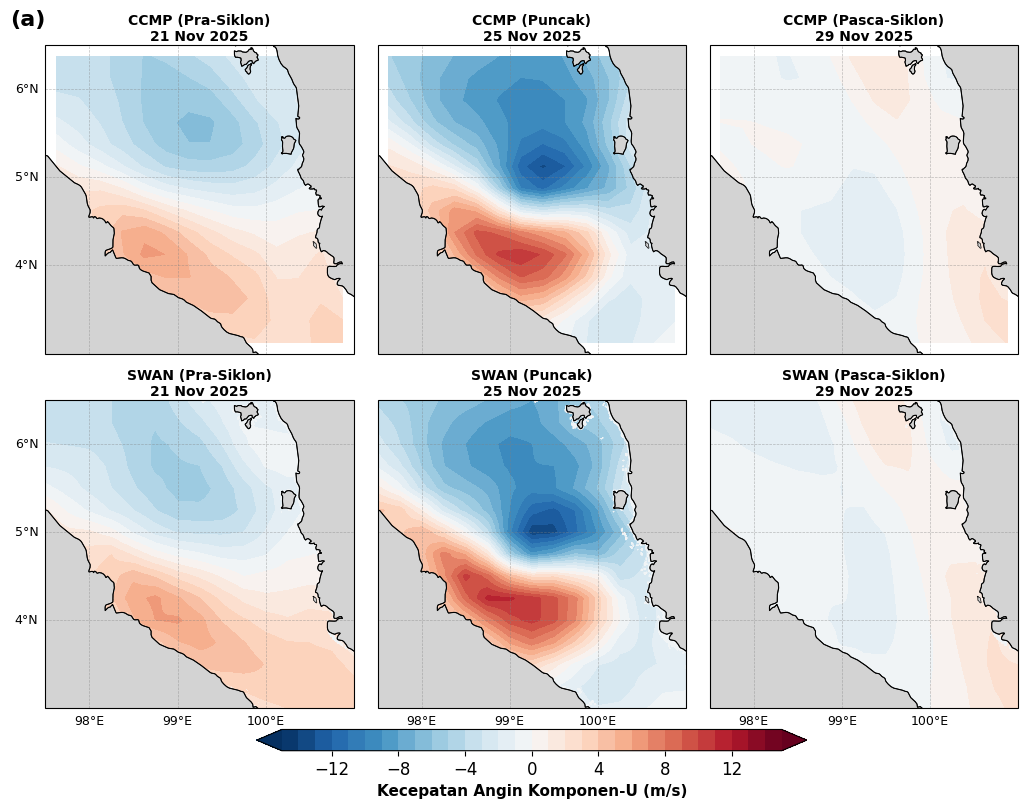

Memproses Gambar Komparasi Super Rapat: Angin-V...


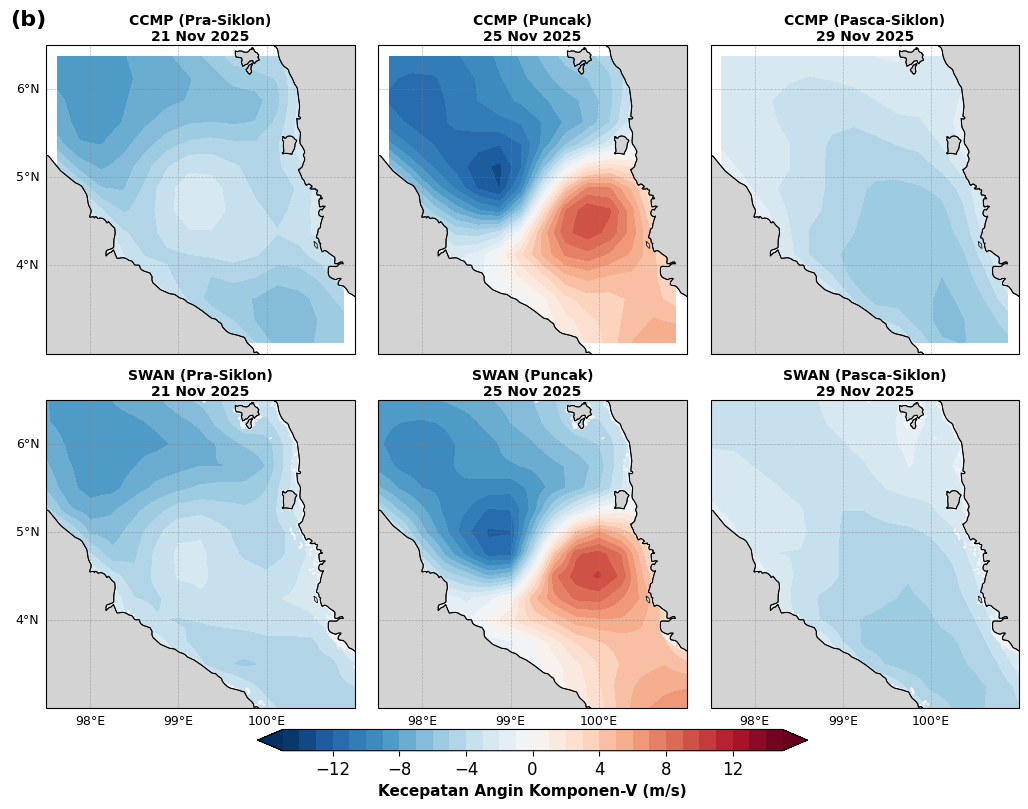

Memproses Gambar Komparasi Super Rapat: SWH...


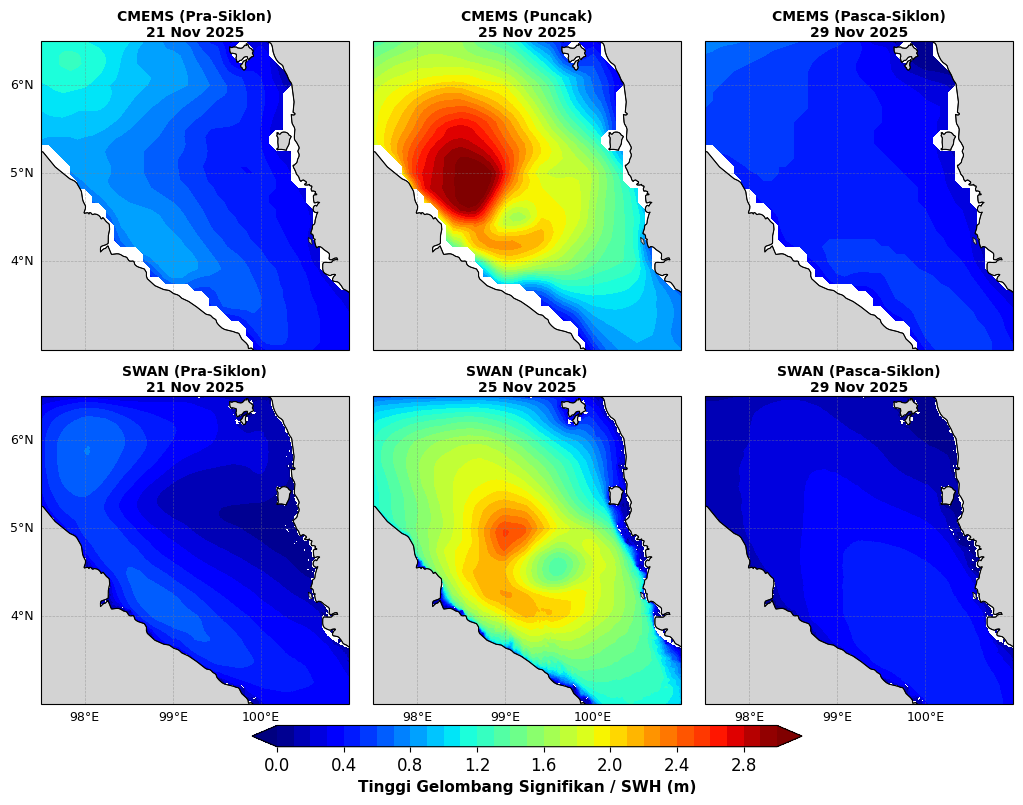

✅ SELESAI


In [5]:
import xarray as xr
import scipy.io as sio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
import os
import warnings

warnings.filterwarnings('ignore')

# =====================================================================
# 1. PENGATURAN FOLDER & PATH FILE
# =====================================================================
output_dir = r"D:\Kuliah\Skripsi\Olah data\Validasi_Data"
os.makedirs(output_dir, exist_ok=True)

file_ccmp_angin = r"D:\Kuliah\Skripsi\Olah data\CCMP_WINDS/*.nc4"
file_cmems_swh = r"D:\Kuliah\Skripsi\Olah data\Data_SWH CMEMS.nc" 
file_swan = r"D:\Kuliah\Skripsi\Olah data\SWAN 2\SWH_Output2.mat"

lon_min, lon_max = 97.5, 101.0
lat_min, lat_max = 3.0, 6.5

# =====================================================================
# 2. LOAD DATA & DEFINISI FASE SIKLON (Pra, Puncak, Pasca)
# =====================================================================
print("Loading data...")
ds_angin = xr.open_mfdataset(file_ccmp_angin, combine='by_coords')
ds_swh = xr.open_dataset(file_cmems_swh)
mat_data = sio.loadmat(file_swan)

# Koordinat Grid untuk Plotting Spasial
lon_era = ds_angin.longitude.values
lat_era = ds_angin.latitude.values
X_era, Y_era = np.meshgrid(lon_era, lat_era)

lon_cmems = ds_swh.longitude.values
lat_cmems = ds_swh.latitude.values
X_cmems, Y_cmems = np.meshgrid(lon_cmems, lat_cmems)

lon_swan_grid = np.linspace(lon_min, lon_max, 423)
lat_swan_grid = np.linspace(lat_min, lat_max, 423)
X_swan, Y_swan = np.meshgrid(lon_swan_grid, lat_swan_grid)

# Definisi tanggal dan jam per fase
fase_list = [
    {'nama': 'Pra-Siklon',  't_nc': '2025-11-21T12:00:00', 't_mat': '20251121_120000', 'tgl': '21 Nov 2025'},
    {'nama': 'Puncak',       't_nc': '2025-11-25T12:00:00', 't_mat': '20251125_120000', 'tgl': '25 Nov 2025'},
    {'nama': 'Pasca-Siklon', 't_nc': '2025-11-29T12:00:00', 't_mat': '20251129_120000', 'tgl': '29 Nov 2025'}
]

# =====================================================================
# 3. FUNGSI STANDARISASI PETA (Layout Ultra Rapat)
# =====================================================================
def format_panel(ax, title, baris, kolom):
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5, zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=3)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.xlocator = mticker.MultipleLocator(1)
    gl.ylocator = mticker.MultipleLocator(1)
    gl.xlabel_style = {'size': 9, 'color': 'black'}
    gl.ylabel_style = {'size': 9, 'color': 'black'}
    
    # Matikan label agar tidak bertabrakan saat dirapatkan
    gl.top_labels = False
    gl.right_labels = False
    if kolom > 0: gl.left_labels = False   
    if baris < 1: gl.bottom_labels = False 
        
    # Judul ditarik turun (pad=3) agar lebih menempel dengan peta
    ax.set_title(title, fontweight='bold', pad=3, fontsize=10)

# =====================================================================
# 4. LOOPING UTAMA GENERASI GAMBAR PER VARIABEL
# =====================================================================
var_config = {
    'Angin-U': {'cmap': 'RdBu_r', 'levels': np.linspace(-15, 15, 31), 'label' : 'Kecepatan Angin Komponen-U (m/s)'},
    'Angin-V': {'cmap': 'RdBu_r', 'levels': np.linspace(-15, 15, 31), 'label': 'Kecepatan Angin Komponen-V (m/s)'},
    'SWH':     {'cmap': 'jet',    'levels': np.arange(0, 3.1, 0.1),  'label': 'Tinggi Gelombang Signifikan / SWH (m)'}
}

for var_name, cfg in var_config.items():
    print(f"Memproses Gambar Komparasi Super Rapat: {var_name}...")
    
    fig, axes = plt.subplots(2, 3, figsize=(11, 8.5), subplot_kw={'projection': ccrs.PlateCarree()})
    
    # 🌟 LOGIKA PENAMBAHAN LABEL (a) dan (b) PADA PANEL KIRI ATAS
    if var_name == 'Angin-U':
        axes[0, 0].text(0.0, 1.05, '(a)', transform=axes[0, 0].transAxes, fontsize=16, fontweight='bold', va='bottom', ha='right', zorder=20)
    elif var_name == 'Angin-V':
        axes[0, 0].text(0.0, 1.05, '(b)', transform=axes[0, 0].transAxes, fontsize=16, fontweight='bold', va='bottom', ha='right', zorder=20)
    # SWH dilewati
    
    for kol_idx, fase in enumerate(fase_list):
        # BARIS 1: DATA PEMBANDING (ERA5 / CMEMS)
        ax_ref = axes[0, kol_idx]
        if var_name == 'Angin-U':
            data_ref = ds_angin['uwnd'].sel(time=fase['t_nc'], method='nearest').values
            X_ref, Y_ref = X_era, Y_era
            source_lbl = "CCMP"
        elif var_name == 'Angin-V':
            data_ref = ds_angin['vwnd'].sel(time=fase['t_nc'], method='nearest').values
            X_ref, Y_ref = X_era, Y_era
            source_lbl = "CCMP"
        else: # SWH
            time_dim = 'time' if 'time' in ds_swh.coords else 'valid_time'
            data_ref = ds_swh['VHM0'].sel({time_dim: fase['t_nc']}, method='nearest').values
            X_ref, Y_ref = X_cmems, Y_cmems
            source_lbl = "CMEMS"
            
        cf_ref = ax_ref.contourf(X_ref, Y_ref, data_ref, levels=cfg['levels'], cmap=cfg['cmap'], extend='both', transform=ccrs.PlateCarree())
        format_panel(ax_ref, f"{source_lbl} ({fase['nama']})\n{fase['tgl']}", 0, kol_idx)

        # BARIS 2: HASEL MODEL SWAN
        ax_swan = axes[1, kol_idx]
        if var_name == 'Angin-U':
            data_swan = mat_data[f'Windv_x_{fase["t_mat"]}']
        elif var_name == 'Angin-V':
            data_swan = mat_data[f'Windv_y_{fase["t_mat"]}']
        else: # SWH
            data_swan = mat_data[f'Hsig_{fase["t_mat"]}']
            
        data_swan = np.where(mat_data[f'Hsig_{fase["t_mat"]}'] <= 0, np.nan, data_swan)
        
        cf_swan = ax_swan.contourf(X_swan, Y_swan, data_swan, levels=cfg['levels'], cmap=cfg['cmap'], extend='both', transform=ccrs.PlateCarree())
        format_panel(ax_swan, f"SWAN ({fase['nama']})\n{fase['tgl']}", 1, kol_idx)

    # -------------------------------------------------------------
    # PENYESUAIAN TATA LETAK ULTRA RAPAT
    # -------------------------------------------------------------
    plt.subplots_adjust(left=0.05, right=0.95, top=0.90, bottom=0.12, wspace=0.02, hspace=0.15)
    
    cbar_ax = fig.add_axes([0.25, 0.07, 0.5, 0.025])
    cbar = fig.colorbar(cf_swan, cax=cbar_ax, orientation='horizontal')
    cbar.set_label(cfg['label'], fontsize=11, fontweight='bold')
    
    file_png = os.path.join(output_dir, f"Validasi_Spasial_3Fase_{var_name}_Rapat.png")
    fig.savefig(file_png, dpi=500, bbox_inches='tight', facecolor='white')
    plt.show(fig) 

print("✅ SELESAI")

In [13]:
import xarray as xr
import scipy.io as sio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import warnings

warnings.filterwarnings('ignore')

# =====================================================================
# 1. PENGATURAN FOLDER & PATH FILE
# =====================================================================
output_dir = r"D:\Kuliah\Skripsi\Olah data\Validasi_Data"
os.makedirs(output_dir, exist_ok=True)

file_ccmp_angin = r"D:\Kuliah\Skripsi\Olah data\CCMP_WINDS/*.nc4"
file_cmems_swh = r"D:\Kuliah\Skripsi\Olah data\Data_SWH CMEMS.nc" 
file_swan = r"D:\Kuliah\Skripsi\Olah data\SWAN 2\SWH_Output2.mat"

# =====================================================================
# 2. DEFINISI KOORDINAT 3 STASIUN VIRTUAL
# =====================================================================
stasiun = {
    'Stasiun 1 (Utara)': (98.25, 5.75),
    'Stasiun 2 (Tengah)': (99.25, 4.50),
    'Stasiun 3 (Selatan)': (100.00, 3.50)
}

# Grid Spasial SWAN
lon_swan_grid = np.linspace(97.5, 101.0, 423)
lat_swan_grid = np.linspace(3.0, 6.5, 423)

# =====================================================================
# 3. LOAD DATA & SINKRONISASI WAKTU
# =====================================================================
print("Loading data dan menyinkronkan waktu...")
ds_angin = xr.open_mfdataset(file_ccmp_angin, combine='by_coords')
ds_swh = xr.open_dataset(file_cmems_swh)
mat_data = sio.loadmat(file_swan)

t_var_ref_a = 'time' 
t_var_ref_s = 'time' if 'time' in ds_swh.coords else 'valid_time'

ds_angin = ds_angin.sel({t_var_ref_a: slice('2025-11-21', '2025-12-02')})
ds_swh = ds_swh.sel({t_var_ref_s: slice('2025-11-21', '2025-12-02')})

t_ref_a = pd.to_datetime(ds_angin[t_var_ref_a].values).strftime('%Y%m%d_%H%M00')
t_ref_s = pd.to_datetime(ds_swh[t_var_ref_s].values).strftime('%Y%m%d_%H%M00')
t_swan = sorted([k.replace('Hsig_', '') for k in mat_data.keys() if k.startswith('Hsig_')])

# Cari irisan waktu lintas data
common_keys = sorted(list(set(t_ref_a) & set(t_ref_s) & set(t_swan)))
common_times_dt = pd.to_datetime(common_keys, format='%Y%m%d_%H%M00')
print(f"✅ Ditemukan {len(common_keys)} titik waktu sinkron untuk Time-Series.")

# =====================================================================
# 4. FUNGSI EKSTRAKSI DATA TIME-SERIES (DIPERBAIKI)
# =====================================================================
def get_time_series(var_name, lon_pt, lat_pt):
    idx_lon = np.argmin(np.abs(lon_swan_grid - lon_pt))
    idx_lat = np.argmin(np.abs(lat_swan_grid - lat_pt))
    
    val_obs, val_model = [], []
    
    for t_dt, t_str in zip(common_times_dt, common_keys):
        if var_name == 'Angin-U':
            obs = ds_angin['uwnd'].sel(time=t_dt, longitude=lon_pt, latitude=lat_pt, method='nearest').values
            mod = mat_data[f'Windv_x_{t_str}'][idx_lat, idx_lon]
        elif var_name == 'Angin-V':
            obs = ds_angin['vwnd'].sel(time=t_dt, longitude=lon_pt, latitude=lat_pt, method='nearest').values
            mod = mat_data[f'Windv_y_{t_str}'][idx_lat, idx_lon]
        else: # SWH
            # 🌟 SOLUSI: Bungkus semua dimensi ke dalam satu dictionary, lalu gunakan ** unpacking
            sel_dict = {t_var_ref_s: t_dt, 'longitude': lon_pt, 'latitude': lat_pt}
            obs = ds_swh['VHM0'].sel(**sel_dict, method='nearest').values
            mod = mat_data[f'Hsig_{t_str}'][idx_lat, idx_lon]
            
        val_obs.append(float(obs))
        val_model.append(float(mod))
        
    return np.array(val_obs), np.array(val_model)

# =====================================================================
# 5. LOOPING PLOTTING TIME-SERIES (POSISI LABEL Y DINAMIS)
# =====================================================================
plt.rcParams.update({'font.size': 12})

# 🌟 SOLUSI: Menambahkan 'pos_x' secara spesifik untuk masing-masing variabel
var_config = {
    'Angin-U': {'label_y': 'Kecepatan Angin-U (m/s)', 'label_panel': '(a)', 'obs_name': 'Satelit CCMP', 'pos_x': 0.06},
    'Angin-V': {'label_y': 'Kecepatan Angin-V (m/s)', 'label_panel': '(b)', 'obs_name': 'Satelit CCMP', 'pos_x': 0.06},
    'SWH':     {'label_y': 'SWH (m)',                 'label_panel': '',    'obs_name': 'Satelit CMEMS', 'pos_x': 0.02}
}

for var_name, cfg in var_config.items():
    print(f"Memproses Grafik Time-Series Terbuka: {var_name}...")
    
    # Membuat 3 subplots vertikal (satu untuk setiap stasiun)
    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    
    # MEMBERI LABEL (a) atau (b) PADA PANEL PALING ATAS
    if cfg['label_panel'] != '':
        axes[0].text(-0.06, 1.35, cfg['label_panel'], transform=axes[0].transAxes, 
                     fontsize=16, fontweight='bold', va='bottom', ha='right', zorder=20)
        
    for i, (nama_stasiun, coords) in enumerate(stasiun.items()):
        ax = axes[i]
        
        # Ekstrak data
        obs_data, mod_data = get_time_series(var_name, coords[0], coords[1])
        
        # Plotting
        ax.plot(common_times_dt, obs_data, color='blue', linewidth=2, label=cfg['obs_name'], marker='o', markersize=4)
        ax.plot(common_times_dt, mod_data, color='red', linewidth=2, linestyle='--', label='Model SWAN')
        
        ax.set_title(nama_stasiun, fontweight='bold', fontsize=12, pad=10)
        ax.grid(True, linestyle='--', alpha=0.6)
        
    # Posisi Legenda
    axes[0].legend(loc='lower center', bbox_to_anchor=(0.5, 1.25), ncol=2, 
                   framealpha=1.0, edgecolor='black', fontsize=11)

    # Format Sumbu X (Tanggal & Jam)
    axes[-1].xaxis.set_major_locator(mdates.DayLocator(interval=1))
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b\n%H:00'))
    plt.xticks(rotation=0)
    
    # Sumbu X tetap dikunci dengan label 'Tanggal'
    axes[-1].set_xlabel('Tanggal', fontweight='bold', fontsize=12)
    
    # 🌟 PERBAIKAN: Memanggil nilai pos_x dari dalam kamus var_config
    fig.supylabel(cfg['label_y'], fontweight='bold', fontsize=14, x=cfg['pos_x'])
    
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.4, top=0.85) 
    
    file_png = os.path.join(output_dir, f"Validasi_TimeSeries_{var_name}.png")
    fig.savefig(file_png, dpi=500, bbox_inches='tight', facecolor='white')
    plt.close(fig)

print(f"✅ Selesai! Seluruh grafik Time-Series dengan tata letak dinamis berhasil disimpan di: {output_dir}")

Loading data dan menyinkronkan waktu...
✅ Ditemukan 47 titik waktu sinkron untuk Time-Series.
Memproses Grafik Time-Series Terbuka: Angin-U...
Memproses Grafik Time-Series Terbuka: Angin-V...
Memproses Grafik Time-Series Terbuka: SWH...
✅ Selesai! Seluruh grafik Time-Series dengan tata letak dinamis berhasil disimpan di: D:\Kuliah\Skripsi\Olah data\Validasi_Data


✅ Peta Lokasi Virtual Buoy berhasil dibuat! Tersimpan di: D:\Kuliah\Skripsi\Olah data\Peta_Lokasi_Virtual_Buoy.png


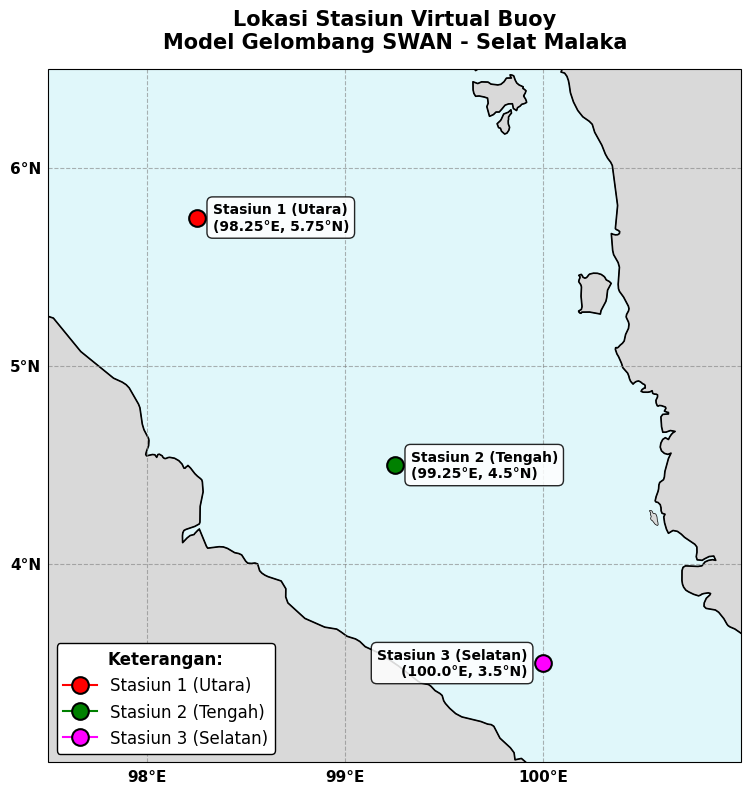

In [4]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
import matplotlib.patches as patches
import os
import warnings

warnings.filterwarnings('ignore')

# =====================================================================
# 1. PENGATURAN FOLDER & PATH FILE OUTPUT
# =====================================================================
output_dir = r"D:\Kuliah\Skripsi\Olah data"
os.makedirs(output_dir, exist_ok=True)
out_png = os.path.join(output_dir, "Peta_Lokasi_Virtual_Buoy.png")

# =====================================================================
# 2. DEFINISI KOORDINAT & WARNA STASIUN (Sesuai Diagram Taylor)
# =====================================================================
stasiun = {
    'Stasiun 1 (Utara)':   {'lon': 98.25,  'lat': 5.75, 'color': 'red'},
    'Stasiun 2 (Tengah)':  {'lon': 99.25,  'lat': 4.50, 'color': 'green'},
    'Stasiun 3 (Selatan)': {'lon': 100.00, 'lat': 3.50, 'color': 'magenta'}
}

# Batas Domain Utama Selat Malaka
lon_min, lon_max = 97.5, 101.0
lat_min, lat_max = 3.0, 6.5

# =====================================================================
# 3. SETUP FIGURE & PETA UTAMA
# =====================================================================
plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})
fig = plt.figure(figsize=(10, 9))

# Membuat Axis Peta Utama
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Menambahkan Daratan, Lautan, dan Garis Pantai
ax.add_feature(cfeature.LAND, facecolor='#d9d9d9', edgecolor='black', linewidth=0.5, zorder=1)
ax.add_feature(cfeature.OCEAN, facecolor='#e0f7fa', zorder=0) # Biru laut pucat
ax.add_feature(cfeature.COASTLINE, linewidth=1.2, zorder=2)

# Mengatur Gridlines (Garis Lintang Bujur)
gl = ax.gridlines(draw_labels=True, linewidth=0.8, color='gray', alpha=0.6, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlocator = mticker.MultipleLocator(1)
gl.ylocator = mticker.MultipleLocator(1)
gl.xlabel_style = {'size': 11, 'color': 'black', 'weight': 'bold'}
gl.ylabel_style = {'size': 11, 'color': 'black', 'weight': 'bold'}

# =====================================================================
# 4. PLOTTING TITIK STASIUN & LABEL KOORDINAT
# =====================================================================
for nama, data in stasiun.items():
    # Menggambar Titik Stasiun (Bulatan bergaris tepi hitam agar menonjol)
    ax.plot(data['lon'], data['lat'], marker='o', color=data['color'], 
            markersize=12, markeredgecolor='black', markeredgewidth=1.5, 
            transform=ccrs.PlateCarree(), label=nama, zorder=4)
    
    # Menambahkan Teks Kotak (Label Nama & Koordinat)
    teks_label = f"{nama}\n({data['lon']}°E, {data['lat']}°N)"
    
    # Sedikit penyesuaian posisi teks agar tidak menabrak titik atau garis pantai
    offset_lon = 0.08
    ha_align = 'left'
    if nama == 'Stasiun 3 (Selatan)': 
        offset_lon = -0.08
        ha_align = 'right' # Stasiun 3 ditaruh di sebelah kiri titik agar tidak menabrak daratan Malaysia
        
    ax.text(data['lon'] + offset_lon, data['lat'], teks_label, 
            transform=ccrs.PlateCarree(), fontsize=10, fontweight='bold', 
            ha=ha_align, va='center', zorder=5,
            bbox=dict(boxstyle='round,pad=0.4', edgecolor='black', facecolor='white', alpha=0.85))

# Menambahkan Judul Peta
ax.set_title("Lokasi Stasiun Virtual Buoy\nModel Gelombang SWAN - Selat Malaka", 
             fontweight='bold', pad=15, fontsize=15)

# Menambahkan Kotak Legenda
ax.legend(loc='lower left', framealpha=1.0, edgecolor='black', title='Keterangan:', title_fontproperties={'weight':'bold'})

# =====================================================================
# 5. PENYIMPANAN
# =====================================================================
fig.savefig(out_png, dpi=600, bbox_inches='tight', facecolor='white')
print(f"✅ Peta Lokasi Virtual Buoy berhasil dibuat! Tersimpan di: {out_png}")